# **II. ANALYSE DE L'AMONT DES SUA**

## **II. 1) Analyse statistique des bases de données réelles des SUA**

### Analyse Mathilde

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [3]:
chemin = 'BD_2016_2020_TableauDynamique.xlsx'
df_original = pd.read_excel(chemin, sheet_name="Extraction juin 2016 juin 2020")

In [4]:
df = df_original.copy()

In [5]:
df.head()

,Num d'ordre,Date,Heure,Informations du passage->date et heure d'arrivée,Informations du passage->moyen d'arrivée,IAO->motif d'entrée,IAO->motif de venue,Patient->age en année,Antécédent->antécédents médicaux,Antécédent->antécédents chirurgicaux,...,Informations du passage->CAC du séjour,Informations du passage->date et heure de sortie,Informations du passage->date début prise en charge médicale,Informations du passage->dossier dans l'hôpital,Orientation->type d'orientation,Orientation->destination,Orientation->tansfert vers le service,Orientation->transfert vers l'hôpital,Patient->code postal de la ville,Patient->nom de la ville
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,...,3093.0,42522.176389,42522.043750,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59139,WATTIGNIES
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,...,3102.0,42522.461806,42522.093056,NaN,TRANSFERT EXTERNE,Transfert CLINIQUE DUBOIS (LILLE) Motif: Conve...,NaN,CLINIQUE DUBOIS,59310,ORCHIES
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,...,3102.0,42522.127778,NaN,NaN,TRANSFERT INTERNE,Admis(e) en NEUROLOGIE B 5 EST (3281/CAC),NEUROLOGIE B 5 EST,NaN,59480,LA BASSEE
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,...,3093.0,42522.201389,42522.081250,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59136,WAVRIN
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,...,3102.0,42522.663194,42522.107639,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59130,LAMBERSART


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336253 entries, 0 to 336252
Data columns (total 41 columns):
 #   Column                                                                        Non-Null Count   Dtype         
---  ------                                                                        --------------   -----         
 0   Num d'ordre                                                                   336253 non-null  int64         
 1   Date                                                                          336253 non-null  datetime64[ns]
 2   Heure                                                                         336253 non-null  object        
 3    Informations du passage->date et heure d'arrivée                             336253 non-null  datetime64[ns]
 4    Informations du passage->moyen d'arrivée                                     334907 non-null  object        
 5    IAO->motif d'entrée                                                          3

In [7]:
df.isna().sum()

Num d'ordre                                                                          0
Date                                                                                 0
Heure                                                                                0
 Informations du passage->date et heure d'arrivée                                    0
 Informations du passage->moyen d'arrivée                                         1346
 IAO->motif d'entrée                                                             24451
 IAO->motif de venue                                                             28719
 Patient->age en année                                                               0
 Antécédent->antécédents médicaux                                               233630
 Antécédent->antécédents chirurgicaux                                           265119
 Constante->Surveillances->PAS/PAD adultes (première valeur)                     93635
 Constante->Surveillances->FC adultes (prem

In [8]:
df.duplicated().sum()

0

In [9]:
# remarques :

# 1) bcp de données non-numériques
# --> variables quali : encoder ça ?
# --> variables quanti :
  #  motif entrée,
  #  motif venue,
  #  antécédents médicaux,
  #  antécédents chirurgicaux,
  #  Orientation->destination
  #  Orientation->tansfert vers le service
  #  Orientation->transfert vers l'hôpital
  #  nom de la ville

# 2) renommer variables prcq là c'est le bordèle

# 3) pas de duplicats donc lourd

# 4) par contre, bcp de na !!

# 5) variable cible ? j'aurais mis le temps pass aux urgences donc date/heure d'arrivée - date/heure de sortie mais à voir

# 6) sélectionner variables indicateurs : en fonction du niveau de corrélation avec notre var cible ? avec bon sens ? ACP ?


In [10]:
# Renommer les colonnes : supprimer espaces, flèches, caractères spéciaux
import re

def clean_column_name(col):
    """Nettoie le nom de colonne : supprime espaces, flèches, caractères spéciaux"""
    # Remplacer les flèches par underscore
    col = col.replace('->', '_')
    col = col.replace('→', '_')
    # Remplacer les espaces par underscore
    col = col.replace(' ', '_')
    # Supprimer les caractères spéciaux
    col = re.sub(r'[^a-zA-Z0-9_]', '', col)
    # Supprimer les underscores multiples
    col = re.sub(r'_+', '_', col)
    # Transformer en minuscules
    col = col.lower()
    return col

df.columns = [clean_column_name(col) for col in df.columns]
print("Colonnes renommées :")
print(df.columns.tolist())

Colonnes renommées :
['num_dordre', 'date', 'heure', '_informations_du_passage_date_et_heure_darrive', '_informations_du_passage_moyen_darrive', '_iao_motif_dentre', '_iao_motif_de_venue', '_patient_age_en_anne', '_antcdent_antcdents_mdicaux', '_antcdent_antcdents_chirurgicaux', '_constante_surveillances_paspad_adultes_premire_valeur', '_constante_surveillances_fc_adultes_premire_valeur', '_constante_surveillances_temprature_adultes_premire_valeur', '_constante_surveillances_sao2_adultes_premire_valeur', '_constante_surveillances_frquence_respiratoire_premire_valeur', '_diagnostic_code_ccmu', '_localisation_salles', '_localisation_date_dentre_en_box', '_anamnse_texte', '_iao_observation', '_examens_complmentaires_a_des_examens_de_biologie', '_examens_complmentaires_a_des_examens_de_radiologie', '_examens_complmentaires_a_des_examens_dchographie', '_examens_complmentaires_a_des_examens_de_scanner', '_examens_complmentaires_a_des_examens_dirm', '_examens_complmentaires_a_des_avis_de_spci

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336253 entries, 0 to 336252
Data columns (total 41 columns):
 #   Column                                                                     Non-Null Count   Dtype         
---  ------                                                                     --------------   -----         
 0   num_dordre                                                                 336253 non-null  int64         
 1   date                                                                       336253 non-null  datetime64[ns]
 2   heure                                                                      336253 non-null  object        
 3   _informations_du_passage_date_et_heure_darrive                             336253 non-null  datetime64[ns]
 4   _informations_du_passage_moyen_darrive                                     334907 non-null  object        
 5   _iao_motif_dentre                                                          311802 non-null  object  

In [12]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

df.head(20)

# à tej : date, heure, iao_motif_dentre( de tte façon on peut pas l'encoder) _anamnse_texte	(dossier patient), _iao_observation, _examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie	

# à encoder : iao_motif_venue, 
# --> _examens_complmentaires_a_des_examens_de_biologie --> mettre en booléen (Encoder)

# à voir : antcdents medicaux, chirurgicaux, _localisation_salles	

# à séparer ; _constante_surveillances_paspad_adultes_premire_valeur

# ne pas suppr les Nan pour : _constante_surveillances_frquence_respiratoire_premire_valeur	et antcdents medicaux, chirurgicaux, 

,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,_constante_surveillances_paspad_adultes_premire_valeur,_constante_surveillances_fc_adultes_premire_valeur,_constante_surveillances_temprature_adultes_premire_valeur,_constante_surveillances_sao2_adultes_premire_valeur,_constante_surveillances_frquence_respiratoire_premire_valeur,_diagnostic_code_ccmu,_localisation_salles,_localisation_date_dentre_en_box,_anamnse_texte,_iao_observation,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie,_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie,_diagnostic_diagnostic_principal_code_diagnostic,_diagnostic_diagnostic_principal_intitul,_informations_du_passage_cac_dadmission,_informations_du_passage_cac_du_sjour,_informations_du_passage_date_et_heure_de_sortie,_informations_du_passage_date_dbut_prise_en_charge_mdicale,_informations_du_passage_dossier_dans_lhpital,_orientation_type_dorientation,_orientation_destination,_orientation_tansfert_vers_le_service,_orientation_transfert_vers_lhpital,_patient_code_postal_de_la_ville,_patient_nom_de_la_ville
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,110/56,52,34.9,97,NaN,1,"((Attente pré IOA,01/06/2016 00:16,01/06/2016 ...",42522.045833,MDC: Dyspnée aiguë et palpitations ATCDS: ...,NaN,oui,oui,non,non,non,non,42522.062500,42522.065972,R06.0,Dyspnée,ACCUEIL SURVEILLANCE ET ADMISSION URGENCE ADUL...,3093.0,42522.176389,42522.043750,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59139,WATTIGNIES
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,90/41,77,36.3,98,NaN,2,"((Attente pré IOA,01/06/2016 00:18,01/06/2016 ...",42522.063889,vient pour hyperthermie ATCD: DID retard ...,NaN,oui,oui,non,non,non,non,42522.065278,42522.065278,R50.9,"Fièvre, sans précision",ACCUEIL SURVEILLANCE ET ADMISSION URGENCE ADUL...,3102.0,42522.461806,42522.093056,NaN,TRANSFERT EXTERNE,Transfert CLINIQUE DUBOIS (LILLE) Motif: Conve...,NaN,CLINIQUE DUBOIS,59310,ORCHIES
2,3,2016-06-01,00:36:00,2016-06-01 00:36:00,POMPIERS,NaN,NaN,77,NaN,NaN,137/77,97,36.5,96,21,2,"((Attente pré IOA,01/06/2016 00:36,01/06/2016 ...",42522.028472,NaN,NaN,non,non,non,non,non,oui,NaN,NaN,R47.1,Dysarthrie et anarthrie,ACCUEIL SURVEILLANCE ET ADMISSION URGENCE ADUL...,3102.0,42522.127778,NaN,NaN,TRANSFERT INTERNE,Admis(e) en NEUROLOGIE B 5 EST (3281/CAC),NEUROLOGIE B 5 EST,NaN,59480,LA BASSEE
3,4,2016-06-01,00:43:00,2016-06-01 00:43:00,MOYENS PERSONNELS,"1A, Hyperthermie ne cédant pas au paracetamol,...",Maladies infectieuses: Hyperthermie,38,NaN,NaN,117/71,118,38.2,98,NaN,1,"((Attente pré IOA,01/06/2016 00:43,01/06/2016 ...",42522.066667,patient de 38 ans appelant le SAMU pour épisod...,NaN,oui,non,non,non,non,non,42522.069444,42522.069444,L98.8,Autres affections précisées de la peau et du t...,ACCUEIL SURVEILLANCE ET ADMISSION URGENCE ADUL...,3093.0,42522.201389,42522.081250,NaN,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59136,WAVRIN
4,5,2016-06-01,01:16:00,2016-06-01 01:16:00,AMBULANCE PRIVEE,"Douleur bras gauche et mollet gauche, hémiplég...",Cardiologie: Phlébite,69,décembre 2007 : infarctus capsulo caudé droit ...,NaN,137/79,70,36.1,97,NaN,2,"((Attente pré IOA,01/06/2016 01:16,01/06/2016 ...",42522.066667,Patiente de 69 ans amenée pour douleur membre ...,NaN,oui,non,non,non,non,oui,42522.065278,42522.065972,M79.62,Douleur au n

In [13]:
# Voir le contenu et le type de _informations_du_passage_date_et_heure_de_sortie
print("Type :", df["_informations_du_passage_date_et_heure_de_sortie"].dtype)
print("\nPremières valeurs :")
print(df["_informations_du_passage_date_et_heure_de_sortie"].head(10))
print("\nExemple détaillé :")
print(df["_informations_du_passage_date_et_heure_de_sortie"].iloc[0])

Type : float64

Premières valeurs :
0    42522.176389
1    42522.461806
2    42522.127778
3    42522.201389
4    42522.663194
5    42522.192361
6    42522.184028
7    42522.172917
8    42522.386806
9    42522.158333
Name: _informations_du_passage_date_et_heure_de_sortie, dtype: float64

Exemple détaillé :
42522.1763888889


In [14]:
# Convertir le format Excel en datetime
df["_informations_du_passage_date_et_heure_de_sortie"] = pd.to_datetime(
    df["_informations_du_passage_date_et_heure_de_sortie"], 
    unit='D', 
    origin='1899-12-30'
)

# Vérifier
print(df["_informations_du_passage_date_et_heure_de_sortie"].head(10))

0   2016-06-01 04:14:00.000001271
1   2016-06-01 11:05:00.000003701
2   2016-06-01 03:04:00.000002040
3   2016-06-01 04:50:00.000000769
4   2016-06-01 15:54:59.999996298
5   2016-06-01 04:36:59.999998858
6   2016-06-01 04:25:00.000002161
7   2016-06-01 04:09:00.000002810
8   2016-06-01 09:17:00.000003952
9   2016-06-01 03:47:59.999996817
Name: _informations_du_passage_date_et_heure_de_sortie, dtype: datetime64[ns]


In [15]:
# Calculer la variable cible : temps passé aux urgences en minutes
df["target_temps_urgences_minutes"] = (
    df["_informations_du_passage_date_et_heure_de_sortie"] - 
    df["_informations_du_passage_date_et_heure_darrive"]
).dt.total_seconds() / 60

print("Variable cible (temps en minutes) :")
print(df["target_temps_urgences_minutes"].describe())


Variable cible (temps en minutes) :
count    3.362530e+05
mean     4.883014e+02
std      1.331230e+03
min     -1.317500e-07
25%      1.370000e+02
50%      2.710000e+02
75%      4.710000e+02
max      3.138990e+05
Name: target_temps_urgences_minutes, dtype: float64


In [16]:
# Afficher sans notation scientifique
pd.set_option('display.float_format', '{:.2f}'.format)

print("Variable cible (temps en minutes) - Format normal :")
print(df["target_temps_urgences_minutes"].describe())

# Vérifier les valeurs négatives
print("\n\nValeurs négatives ou très petites :")
print(df[df["target_temps_urgences_minutes"] < 0]["target_temps_urgences_minutes"].head(10))
print(f"\nNombre de valeurs négatives : {(df['target_temps_urgences_minutes'] < 0).sum()}")

# Vérifier les valeurs extrêmes
print("\n\nTop 10 des valeurs les plus élevées (en heures) :")
print((df["target_temps_urgences_minutes"] / 60).nlargest(10))

Variable cible (temps en minutes) - Format normal :
count   336253.00
mean       488.30
std       1331.23
min         -0.00
25%        137.00
50%        271.00
75%        471.00
max     313899.00
Name: target_temps_urgences_minutes, dtype: float64


Valeurs négatives ou très petites :
1668     -0.00
44270    -0.00
65459    -0.00
74041    -0.00
75769    -0.00
118368   -0.00
266049   -0.00
284421   -0.00
329851   -0.00
329864   -0.00
Name: target_temps_urgences_minutes, dtype: float64

Nombre de valeurs négatives : 10


Top 10 des valeurs les plus élevées (en heures) :
283056   5231.65
266355   4406.32
227723   3744.70
177449   1805.45
204024   1707.43
243651   1631.53
309996   1498.05
262207   1481.93
97841    1280.95
284821   1204.27
Name: target_temps_urgences_minutes, dtype: float64


In [17]:
# Vérifier les lignes avec "NON PRIS EN CHARGE"
print("Nombre de cas 'NON PRIS EN CHARGE' :")
print((df["_orientation_destination"] == "NON PRIS EN CHARGE").sum())

print("\nPremiers cas 'NON PRIS EN CHARGE' :")
print(df[df["_orientation_destination"] == "NON PRIS EN CHARGE"].head())

Nombre de cas 'NON PRIS EN CHARGE' :
10705

Premiers cas 'NON PRIS EN CHARGE' :
     num_dordre       date     heure  \
30           31 2016-06-01  09:09:00   
35           36 2016-06-01  09:27:00   
39           40 2016-06-01  09:37:00   
173         174 2016-06-01  18:42:00   
205         206 2016-06-01  21:26:00   

    _informations_du_passage_date_et_heure_darrive  \
30                             2016-06-01 09:09:00   
35                             2016-06-01 09:27:00   
39                             2016-06-01 09:37:00   
173                            2016-06-01 18:42:00   
205                            2016-06-01 21:26:00   

    _informations_du_passage_moyen_darrive  \
30                       MOYENS PERSONNELS   
35                       MOYENS PERSONNELS   
39                        AMBULANCE PRIVEE   
173                      MOYENS PERSONNELS   
205                       AMBULANCE PRIVEE   

                                     _iao_motif_dentre    _iao_motif_de_venue

In [18]:
# Comparer les patients non pris en charge vs temps passé nul/négatif
non_pris_en_charge = df["_orientation_destination"] == "NON PRIS EN CHARGE"
temps_nul_negatif = df["target_temps_urgences_minutes"] <= 0

print("=" * 70)
print("COMPARAISON : Non pris en charge vs Temps nul/négatif")
print("=" * 70)

print(f"\nNombre de patients NON PRIS EN CHARGE : {non_pris_en_charge.sum()}")
print(f"Nombre de patients avec temps <= 0 minutes : {temps_nul_negatif.sum()}")

print(f"\n\nChevauchement (à la fois non pris en charge ET temps <= 0) : {(non_pris_en_charge & temps_nul_negatif).sum()}")
print(f"Non pris en charge MAIS temps > 0 : {(non_pris_en_charge & ~temps_nul_negatif).sum()}")
print(f"Temps <= 0 MAIS pris en charge : {(~non_pris_en_charge & temps_nul_negatif).sum()}")

print("\n" + "=" * 70)
print("Patients NON PRIS EN CHARGE - Analyse du temps")
print("=" * 70)
print(df[non_pris_en_charge]["target_temps_urgences_minutes"].describe())

print("\n" + "=" * 70)
print("Patients avec TEMPS <= 0 - Analyse de l'orientation")
print("=" * 70)
print(df[temps_nul_negatif]["_orientation_destination"].value_counts())

print("\n" + "=" * 70)
print("Exemples : Temps <= 0 mais pris en charge")
print("=" * 70)
print(df[~non_pris_en_charge & temps_nul_negatif][["_orientation_destination", "target_temps_urgences_minutes"]].head(10))

COMPARAISON : Non pris en charge vs Temps nul/négatif

Nombre de patients NON PRIS EN CHARGE : 10705
Nombre de patients avec temps <= 0 minutes : 11


Chevauchement (à la fois non pris en charge ET temps <= 0) : 9
Non pris en charge MAIS temps > 0 : 10696
Temps <= 0 MAIS pris en charge : 2

Patients NON PRIS EN CHARGE - Analyse du temps
count   10705.00
mean      131.71
std      1062.92
min        -0.00
25%        13.00
50%        27.00
75%        97.00
max     89883.00
Name: target_temps_urgences_minutes, dtype: float64

Patients avec TEMPS <= 0 - Analyse de l'orientation
_orientation_destination
NON PRIS EN CHARGE                         9
RETOUR DOMICILE                            1
Admis(e) en RÉANIMATION A HC (5344/CAC)    1
Name: count, dtype: int64

Exemples : Temps <= 0 mais pris en charge
                       _orientation_destination  target_temps_urgences_minutes
148668                          RETOUR DOMICILE                           0.00
284421  Admis(e) en RÉANIMATION A

In [19]:
# montrer les lignes dont la variable cible est négative ou nulle
print("\n" + "=" * 70)
print("Lignes avec temps aux urgences <= 0 minutes")
print("=" * 70)
print(df[df["target_temps_urgences_minutes"] <= 0].head(20))


Lignes avec temps aux urgences <= 0 minutes
        num_dordre       date     heure  \
1668          1669 2016-06-08  14:25:00   
44270        44271 2016-12-12  15:09:00   
65459        65460 2017-03-14  12:05:00   
74041        74042 2017-04-19  16:40:00   
75769        75770 2017-04-26  19:06:00   
118368      118369 2017-10-22  00:11:00   
148668      148669 2018-02-25  18:00:00   
266049      266050 2019-07-04  14:33:00   
284421      284422 2019-09-22  19:29:00   
329851      329852 2020-04-20  11:59:00   
329864      329865 2020-04-20  13:03:00   

       _informations_du_passage_date_et_heure_darrive  \
1668                              2016-06-08 14:25:00   
44270                             2016-12-12 15:09:00   
65459                             2017-03-14 12:05:00   
74041                             2017-04-19 16:40:00   
75769                             2017-04-26 19:06:00   
118368                            2017-10-22 00:11:00   
148668                            2018-

In [20]:
df["_orientation_type_dorientation"].unique()

array(['RETOUR DOMICILE', 'TRANSFERT EXTERNE', 'TRANSFERT INTERNE',
       'CONTRE AVIS', 'PARTIE SANS ATTENDRE', 'NON PRIS EN CHARGE',
       'FUGUE', 'DECES', 'POLICE'], dtype=object)

In [21]:
df.iloc[1668, :]

num_dordre                                                                                                                1669
date                                                                                                       2016-06-08 00:00:00
heure                                                                                                                 14:25:00
_informations_du_passage_date_et_heure_darrive                                                             2016-06-08 14:25:00
_informations_du_passage_moyen_darrive                                                                                     NaN
_iao_motif_dentre                                                                                                          NaN
_iao_motif_de_venue                                                                                                        NaN
_patient_age_en_anne                                                                                           

In [22]:
df.iloc[283056, :]

num_dordre                                                                                                              283057
date                                                                                                       2019-09-16 00:00:00
heure                                                                                                                 21:50:00
_informations_du_passage_date_et_heure_darrive                                                             2019-09-16 21:50:00
_informations_du_passage_moyen_darrive                                                                      AMB PUBLIQUE CHRU 
_iao_motif_dentre                                                                                                          NaN
_iao_motif_de_venue                                                                                                        NaN
_patient_age_en_anne                                                                                           

(array([7.2275e+04, 7.7975e+04, 6.2420e+04, 4.1914e+04, 2.3842e+04,
        1.2898e+04, 7.2760e+03, 4.8310e+03, 3.8510e+03, 3.5310e+03,
        3.2150e+03, 2.8740e+03, 2.6360e+03, 2.1890e+03, 1.7570e+03,
        1.1210e+03, 6.6900e+02, 4.1600e+02, 3.9100e+02, 4.3500e+02,
        5.1000e+02, 6.2900e+02, 6.6900e+02, 6.8600e+02, 6.9800e+02,
        6.4200e+02, 5.2000e+02, 3.3600e+02, 2.0300e+02, 1.4900e+02,
        1.3500e+02, 1.7500e+02, 2.1200e+02, 2.3000e+02, 2.7400e+02,
        3.0600e+02, 2.8800e+02, 2.7200e+02, 1.9800e+02, 1.3900e+02,
        8.5000e+01, 5.7000e+01, 5.1000e+01, 5.2000e+01, 8.4000e+01,
        1.2700e+02, 9.7000e+01, 1.5100e+02, 1.3100e+02, 1.0700e+02]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  9

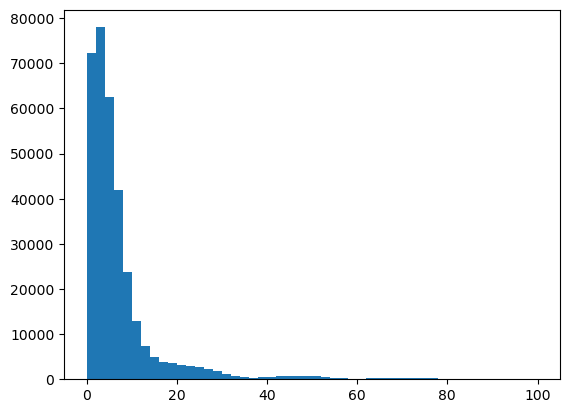

In [23]:
from matplotlib import pyplot as plt    
plt.hist(x=df["target_temps_urgences_minutes"] / 60, bins=50, range=(0, 100))

In [24]:
df["target_temps_urgences_minutes"].head(20)

0     238.00
1     647.00
2     148.00
3     247.00
4     879.00
5     197.00
6     175.00
7     146.00
8     452.00
9      95.00
10    512.00
11    153.00
12    413.00
13    100.00
14     85.00
15     48.00
16    341.00
17     54.00
18   2017.00
19    612.00
Name: target_temps_urgences_minutes, dtype: float64

In [25]:
df["_informations_du_passage_date_et_heure_darrive"].head(20)

0    2016-06-01 00:16:00
1    2016-06-01 00:18:00
2    2016-06-01 00:36:00
3    2016-06-01 00:43:00
4    2016-06-01 01:16:00
5    2016-06-01 01:20:00
6    2016-06-01 01:30:00
7    2016-06-01 01:43:00
8    2016-06-01 01:45:00
9    2016-06-01 02:13:00
10   2016-06-01 02:24:00
11   2016-06-01 02:27:00
12   2016-06-01 03:29:00
13   2016-06-01 04:12:00
14   2016-06-01 04:16:00
15   2016-06-01 04:34:00
16   2016-06-01 04:45:00
17   2016-06-01 06:03:00
18   2016-06-01 06:23:00
19   2016-06-01 06:28:00
Name: _informations_du_passage_date_et_heure_darrive, dtype: datetime64[ns]

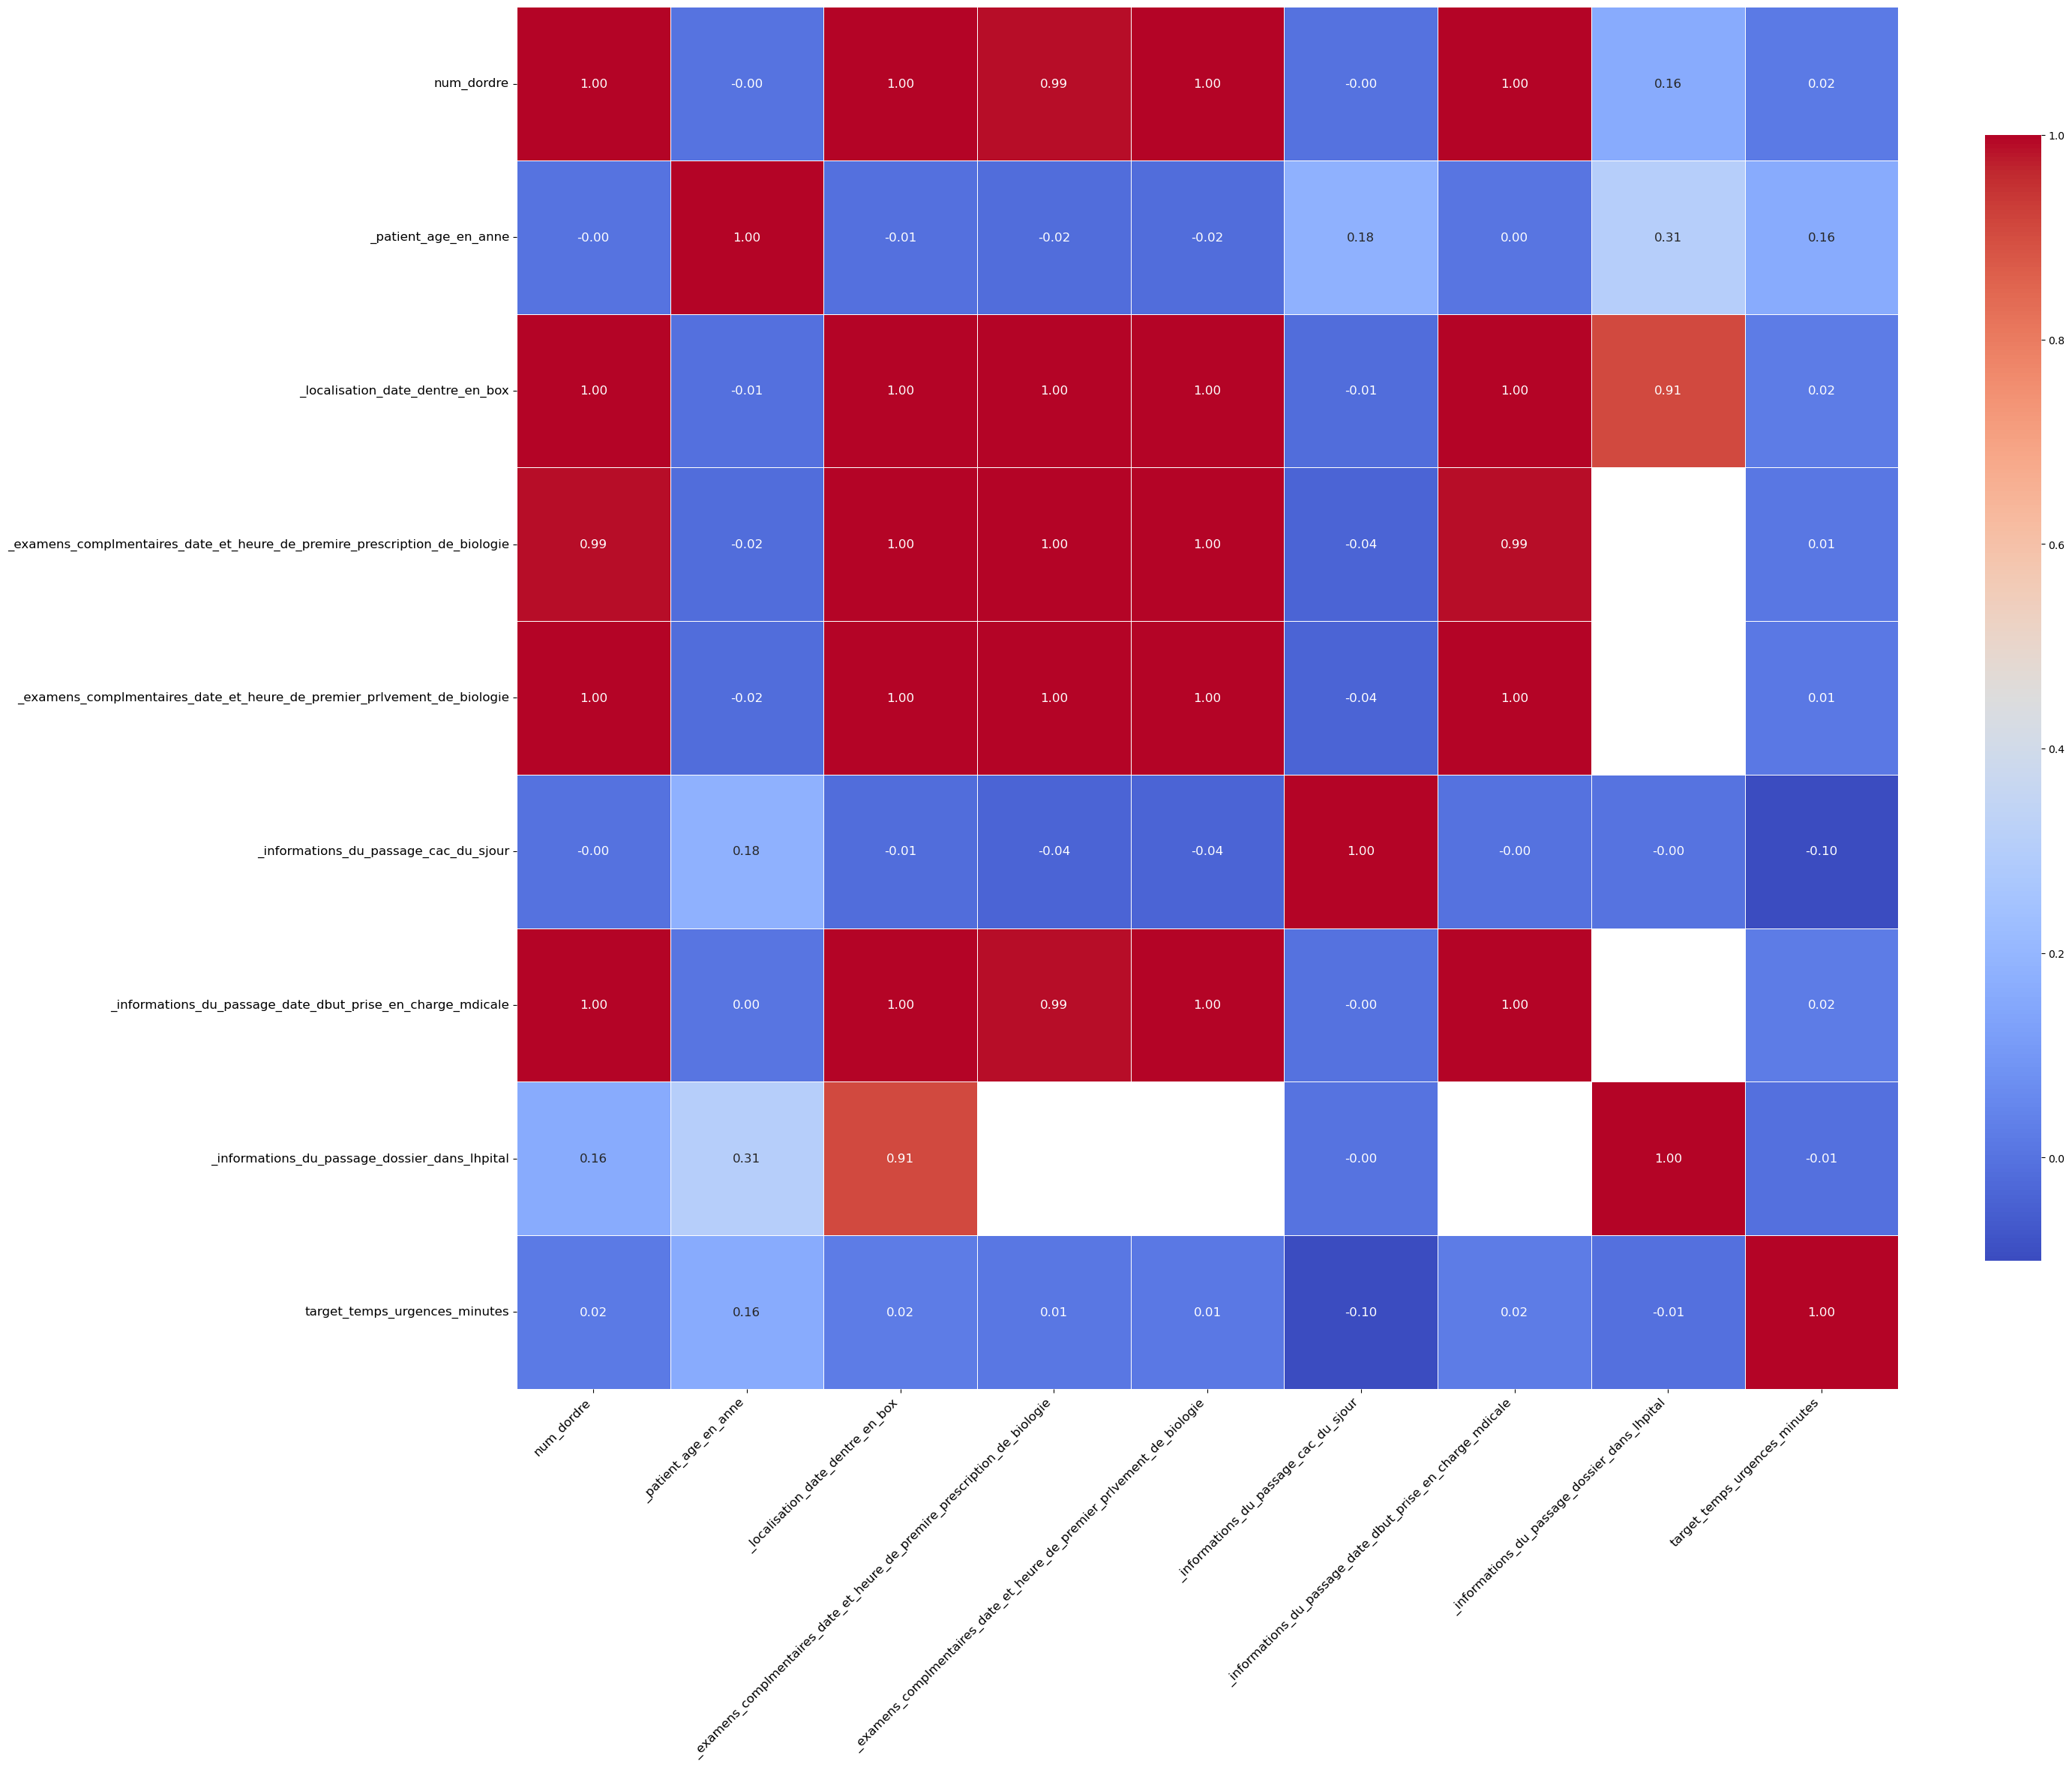

In [26]:
# matrice de corrélation
plt.figure(figsize=(30, 24))
sns.heatmap(df.select_dtypes(include=[float, int]).corr(method='pearson'), 
            cmap='coolwarm', annot=True, fmt='.2f', square=True, 
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 12}, linewidths=0.5)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## Analyse Aya : 
Interprétations + ACP 

In [27]:
# Résumé nettoyage 
import pandas as pd
import numpy as np

# 1) Rappel global
print("=== INFO DF ===")
print(df.info())

# 2) Aperçu général
print("\n=== HEAD ===")
print(df.head(3))

# 3) Inspection de la colonne heure
print("\n=== échantillon 'heure' ===")
print(df['heure'].dropna().unique()[:20])  # premières modalités

# 4) Inspection des constantes vitales (formattage texte ? avec / ? virgules ?)
const_cols = [
    '_constante_surveillances_paspad_adultes_premire_valeur',
    '_constante_surveillances_fc_adultes_premire_valeur',
    '_constante_surveillances_temprature_adultes_premire_valeur',
    '_constante_surveillances_sao2_adultes_premire_valeur',
    '_constante_surveillances_frquence_respiratoire_premire_valeur'
]

for col in const_cols:
    print(f"\n=== échantillon '{col}' ===")
    print(df[col].dropna().astype(str).unique()[:20])

# 5) Inspection des colonnes date en float (pour voir le format)
date_float_cols = [
    '_localisation_date_dentre_en_box',
    '_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie',
    '_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie',
    '_informations_du_passage_date_dbut_prise_en_charge_mdicale',
    '_informations_du_passage_dossier_dans_lhpital'
]

for col in date_float_cols:
    print(f"\n=== stats '{col}' ===")
    print(df[col].describe())
    print(df[col].dropna().head())


=== INFO DF ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336253 entries, 0 to 336252
Data columns (total 42 columns):
 #   Column                                                                     Non-Null Count   Dtype         
---  ------                                                                     --------------   -----         
 0   num_dordre                                                                 336253 non-null  int64         
 1   date                                                                       336253 non-null  datetime64[ns]
 2   heure                                                                      336253 non-null  object        
 3   _informations_du_passage_date_et_heure_darrive                             336253 non-null  datetime64[ns]
 4   _informations_du_passage_moyen_darrive                                     334907 non-null  object        
 5   _iao_motif_dentre                                                          311802 no

In [28]:
# Nettoyage des variables
import numpy as np
import pandas as pd
import re

df = df.copy()  # pour travailler proprement

# 1) On supprime la colonne quasi vide
if '_informations_du_passage_dossier_dans_lhpital' in df.columns:
    df = df.drop(columns=['_informations_du_passage_dossier_dans_lhpital'])


# 2) Heure d'arrivée : extraire juste l'heure (0-23)
df['heure_arrivee'] = df['heure'].apply(
    lambda t: t.hour if pd.notnull(t) else np.nan
)


# 3) Fonctions utilitaires pour nettoyer les constantes vitales
def parse_paspad(val):
    """
    Transforme '120/80' -> (120.0, 80.0)
    Si format bizarre (ex: '44122'), renvoie (NaN, NaN)
    """
    if pd.isna(val):
        return (np.nan, np.nan)
    s = str(val).strip()
    if '/' in s:
        a, b = s.split('/', 1)
        # on garde seulement les chiffres/points dans chaque partie
        a = re.findall(r'(\d+(\.\d+)?)', a.replace(',', '.'))
        b = re.findall(r'(\d+(\.\d+)?)', b.replace(',', '.'))
        pas = float(a[0][0]) if a else np.nan
        pad = float(b[0][0]) if b else np.nan
        return (pas, pad)
    else:
        # cas comme '44122' -> on ne fait pas confiance
        return (np.nan, np.nan)


def clean_numeric_str(val):
    """
    Nettoie une valeur numérique sous forme de chaîne :
    - enlève espaces
    - remplace virgules par des points
    - récupère le premier nombre trouvé
    """
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in ['', 'nan']:
        return np.nan
    s = s.replace(',', '.')
    m = re.search(r'(\d+(\.\d+)?)', s)
    if m:
        return float(m.group(1))
    else:
        return np.nan


# 4) Appliquer aux constantes vitales
# PAS / PAD
pas_pad = df['_constante_surveillances_paspad_adultes_premire_valeur'].apply(parse_paspad)
df['pas'] = pas_pad.apply(lambda x: x[0])
df['pad'] = pas_pad.apply(lambda x: x[1])

# Fréquence cardiaque
df['fc'] = df['_constante_surveillances_fc_adultes_premire_valeur'].apply(clean_numeric_str)

# Température
df['temperature'] = df['_constante_surveillances_temprature_adultes_premire_valeur'].apply(clean_numeric_str)

# Saturation O2
df['sao2'] = df['_constante_surveillances_sao2_adultes_premire_valeur'].apply(clean_numeric_str)

# Fréquence respiratoire
df['fr'] = df['_constante_surveillances_frquence_respiratoire_premire_valeur'].apply(clean_numeric_str)


# 5) Conversion des dates en float -> datetime (style Excel)
date_float_cols = [
    '_localisation_date_dentre_en_box',
    '_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie',
    '_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie',
    '_informations_du_passage_date_dbut_prise_en_charge_mdicale'
]

for col in date_float_cols:
    if col in df.columns:
        df[col + '_dt'] = pd.to_datetime(
            df[col],
            unit='D',
            origin='1899-12-30',
            errors='coerce'
        )

# 6) Petit check visuel
print(df[['heure', 'heure_arrivee']].head())
print(df[['pas', 'pad', 'fc', 'temperature', 'sao2', 'fr']].head())
for col in date_float_cols:
    print(f"\n{col}_dt :")
    print(df[[col, col + '_dt']].head())


      heure  heure_arrivee
0  00:16:00              0
1  00:18:00              0
2  00:36:00              0
3  00:43:00              0
4  01:16:00              1
     pas   pad     fc  temperature  sao2    fr
0 110.00 56.00  52.00        34.90 97.00   NaN
1  90.00 41.00  77.00        36.30 98.00   NaN
2 137.00 77.00  97.00        36.50 96.00 21.00
3 117.00 71.00 118.00        38.20 98.00   NaN
4 137.00 79.00  70.00        36.10 97.00   NaN

_localisation_date_dentre_en_box_dt :
   _localisation_date_dentre_en_box _localisation_date_dentre_en_box_dt
0                          42522.05       2016-06-01 01:05:59.999997189
1                          42522.06       2016-06-01 01:32:00.000001020
2                          42522.03       2016-06-01 00:40:59.999997959
3                          42522.07       2016-06-01 01:36:00.000003061
4                          42522.07       2016-06-01 01:36:00.000003061

_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie_dt :
   _e

In [29]:
# Vérif des temps 
# 1) Datetimes de référence
df['datetime_arrivee'] = df['_informations_du_passage_date_et_heure_darrive']
df['datetime_sortie'] = df['_informations_du_passage_date_et_heure_de_sortie']

# 2) Recalcul du temps total (en minutes)
df['delai_total_calc'] = (
    df['datetime_sortie'] - df['datetime_arrivee']
).dt.total_seconds() / 60

# 3) Différence avec la cible (pour vérifier la cohérence)
df['diff_target_delai'] = df['target_temps_urgences_minutes'] - df['delai_total_calc']

print("=== Comparaison target vs delai_total_calc ===")
print(df[['target_temps_urgences_minutes', 'delai_total_calc', 'diff_target_delai']].head())
print("\nRésumé statistique de la différence :")
print(df['diff_target_delai'].describe())

# 4) Délais internes : arrivée -> PEC médicale / arrivée -> entrée en box
df['delai_arrivee_PEC'] = (
    df['_informations_du_passage_date_dbut_prise_en_charge_mdicale_dt'] - df['datetime_arrivee']
).dt.total_seconds() / 60

df['delai_arrivee_box'] = (
    df['_localisation_date_dentre_en_box_dt'] - df['datetime_arrivee']
).dt.total_seconds() / 60

print("\n=== Aperçu des délais internes ===")
print(df[['delai_arrivee_PEC', 'delai_arrivee_box']].head())

print("\nRésumé délais arrivée -> PEC :")
print(df['delai_arrivee_PEC'].describe())

print("\nRésumé délais arrivée -> box :")
print(df['delai_arrivee_box'].describe())



=== Comparaison target vs delai_total_calc ===
   target_temps_urgences_minutes  delai_total_calc  diff_target_delai
0                         238.00            238.00               0.00
1                         647.00            647.00               0.00
2                         148.00            148.00               0.00
3                         247.00            247.00               0.00
4                         879.00            879.00               0.00

Résumé statistique de la différence :
count   336253.00
mean         0.00
std          0.00
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          0.00
Name: diff_target_delai, dtype: float64

=== Aperçu des délais internes ===
   delai_arrivee_PEC  delai_arrivee_box
0              47.00              50.00
1             116.00              74.00
2                NaN               5.00
3              74.00              53.00
4              79.00              20.00

Résumé délais arrivée -> PEC :
co

In [30]:
# Indicateurs cliniques organisationnels 
import numpy as np
import pandas as pd
import re

df = df.copy()

# 1) Variables temporelles : jour de semaine & weekend
df['jour_semaine'] = df['date'].dt.dayofweek  # 0 = lundi, ..., 6 = dimanche
df['is_weekend'] = df['jour_semaine'].isin([5, 6]).astype(int)


# 2) Fonction pour transformer oui/non -> 0/1
def to_bool01(val):
    if pd.isna(val):
        return 0  # on considère NA comme "non réalisé"
    s = str(val).strip().lower()
    if s.startswith('oui'):
        return 1
    if s.startswith('non') or s in ['', 'nan']:
        return 0
    # cas bizarre -> NaN pour qu'on le voie éventuellement
    return np.nan


exam_cols = [
    '_examens_complmentaires_a_des_examens_de_biologie',
    '_examens_complmentaires_a_des_examens_de_radiologie',
    '_examens_complmentaires_a_des_examens_dchographie',
    '_examens_complmentaires_a_des_examens_de_scanner',
    '_examens_complmentaires_a_des_examens_dirm',
    '_examens_complmentaires_a_des_avis_de_spcialistes'
]

for col in exam_cols:
    new_col = col + '_01'
    df[new_col] = df[col].apply(to_bool01)


# 3) Scores de ressources utilisées
df['exam_bio'] = df['_examens_complmentaires_a_des_examens_de_biologie_01']
df['exam_radio'] = df['_examens_complmentaires_a_des_examens_de_radiologie_01']
df['exam_echo'] = df['_examens_complmentaires_a_des_examens_dchographie_01']
df['exam_scanner'] = df['_examens_complmentaires_a_des_examens_de_scanner_01']
df['exam_irm'] = df['_examens_complmentaires_a_des_examens_dirm_01']
df['avis_specialiste'] = df['_examens_complmentaires_a_des_avis_de_spcialistes_01']

# nombre d'examens d'imagerie
df['nb_exam_imagerie'] = df[['exam_radio', 'exam_echo', 'exam_scanner', 'exam_irm']].sum(axis=1)

# score de ressources (tu pourras adapter les pondérations plus tard)
df['score_ressources'] = (
    1 * df['exam_bio'] +
    1 * df['exam_radio'] +
    2 * df['exam_scanner'] +
    2 * df['exam_irm'] +
    1 * df['avis_specialiste']
)


# 4) Antécédents : présence/absence
df['has_ant_med'] = df['_antcdent_antcdents_mdicaux'].notna().astype(int)
df['has_ant_chir'] = df['_antcdent_antcdents_chirurgicaux'].notna().astype(int)


# 5) Orientation : hospitalisation / transfert
orient = df['_orientation_type_dorientation'].astype(str).str.upper().str.strip()

df['is_retour_domicile'] = orient.str.contains('RETOUR DOMICILE', na=False).astype(int)
df['is_transfert'] = orient.str.contains('TRANSFERT', na=False).astype(int)
df['is_hospit'] = ((df['is_retour_domicile'] == 0) & (df['is_transfert'] == 0)).astype(int)

# 6) Petit résumé des nouvelles variables
print("=== Aperçu variables créées ===")
print(df[['jour_semaine', 'is_weekend',
          'exam_bio', 'exam_radio', 'exam_echo', 'exam_scanner', 'exam_irm',
          'avis_specialiste', 'nb_exam_imagerie', 'score_ressources',
          'has_ant_med', 'has_ant_chir',
          'is_retour_domicile', 'is_transfert', 'is_hospit']].head())

print("\n=== Stats score_ressources ===")
print(df['score_ressources'].describe())

print("\n=== Taux hospitalisation / transfert / retour domicile ===")
print(df[['is_retour_domicile', 'is_transfert', 'is_hospit']].mean())


=== Aperçu variables créées ===
   jour_semaine  is_weekend  exam_bio  exam_radio  exam_echo  exam_scanner  \
0             2           0         1           1          0             0   
1             2           0         1           1          0             0   
2             2           0         0           0          0             0   
3             2           0         1           0          0             0   
4             2           0         1           0          0             0   

   exam_irm  avis_specialiste  nb_exam_imagerie  score_ressources  \
0         0                 0                 1                 2   
1         0                 0                 1                 2   
2         0                 1                 0                 1   
3         0                 0                 0                 1   
4         0                 1                 0                 2   

   has_ant_med  has_ant_chir  is_retour_domicile  is_transfert  is_hospit  
0       

In [31]:
# Liste initiale
num_vars = [
    '_patient_age_en_anne',
    'heure_arrivee',
    'pas', 'pad', 'fc', 'temperature', 'sao2', 'fr',
    'delai_arrivee_PEC', 'delai_arrivee_box',
    'score_ressources', 'nb_exam_imagerie',
    'exam_bio', 'exam_radio', 'exam_echo', 'exam_scanner', 'exam_irm',
    'avis_specialiste',
    'has_ant_med', 'has_ant_chir',
    'is_weekend', 'is_retour_domicile', 'is_transfert', 'is_hospit'
]

# Ne garder que celles présentes
num_vars = [v for v in num_vars if v in df.columns]

# Corr Spearman
corr_df = df[num_vars + ['target_temps_urgences_minutes']].corr(method='spearman')

# Extraire juste la colonne de corrélation avec la cible
corr_target = corr_df['target_temps_urgences_minutes']

# On retire la corr cible-cible
corr_target = corr_target.drop('target_temps_urgences_minutes', errors='ignore')

# Trier pour obtenir positives et négatives
corr_pos = corr_target.sort_values(ascending=False)  # les plus positifs
corr_neg = corr_target.sort_values(ascending=True)   # les plus négatifs

print("=== TOP 10 corrélations POSITIVES ===")
print(corr_pos.head(10))

print("\n=== TOP 10 corrélations NÉGATIVES ===")
print(corr_neg.head(10))


=== TOP 10 corrélations POSITIVES ===
exam_bio               0.59
score_ressources       0.56
nb_exam_imagerie       0.44
is_transfert           0.39
exam_scanner           0.38
delai_arrivee_PEC      0.35
_patient_age_en_anne   0.34
delai_arrivee_box      0.26
has_ant_med            0.26
exam_echo              0.21
Name: target_temps_urgences_minutes, dtype: float64

=== TOP 10 corrélations NÉGATIVES ===
is_retour_domicile   -0.25
is_hospit            -0.19
sao2                 -0.16
fr                   -0.12
pad                  -0.11
is_weekend           -0.08
heure_arrivee        -0.06
pas                  -0.02
fc                    0.03
avis_specialiste      0.03
Name: target_temps_urgences_minutes, dtype: float64


exam_bio (0.59), score_ressources (0.56), nb_exam_imagerie (0.44), exam_scanner (0.38)
⟶ Plus il y a d’examens (surtout bio + imagerie lourde), plus le passage est long → logique : parcours complexe / explorations complètes.
is_transfert (0.39)
⟶ Les patients transférés restent plus longtemps (temps de coordination, stabilisation, attente de place, etc.).
delai_arrivee_PEC (0.35), delai_arrivee_box (0.26)
⟶ Plus la prise en charge initiale est tardive, plus le passage total est long (effet engorgement).
age (0.34), has_ant_med (0.26)
⟶ Patients plus âgés + avec antécédents = parcours plus long (plus fragile, plus de bilans).
Corrélations négatives (temps PLUS court) :
is_retour_domicile (-0.25)
⟶ Logique : passages simples, retour direct.
is_hospit (-0.19)
⟶ Probable effet pervers : les vraies hospit directes sont parfois plus rapides (décision rapide + filière connue) vs certains transferts compliqués.
sao2 (-0.16), fr (-0.12), pad (-0.11)
⟶ À interpréter avec prudence (données manquantes, patients graves vus plus vite, etc.).

In [32]:
# Préparation ACP
import numpy as np
import pandas as pd

# 1) Quantiles des délais pour repérer les extrêmes
delay_cols = ['delai_arrivee_PEC', 'delai_arrivee_box']

for col in delay_cols:
    print(f"\n=== Quantiles pour {col} ===")
    print(df[col].quantile([0.5, 0.9, 0.95, 0.99, 0.999]))
    print("Max :", df[col].max())

# 2) On crée des versions "capées" (winsorisation grossière au 99e percentile)
for col in delay_cols:
    q99 = df[col].quantile(0.99)
    new_col = col + '_cap'
    df[new_col] = df[col].clip(lower=0, upper=q99)

# Petit check
print("\n=== Aperçu des colonnes capées ===")
print(df[['delai_arrivee_PEC', 'delai_arrivee_PEC_cap',
          'delai_arrivee_box', 'delai_arrivee_box_cap']].head())



=== Quantiles pour delai_arrivee_PEC ===
0.50     83.00
0.90    256.00
0.95    331.00
0.99    512.00
1.00   1026.00
Name: delai_arrivee_PEC, dtype: float64
Max : 69448.99999997232

=== Quantiles pour delai_arrivee_box ===
0.50     43.00
0.90    205.00
0.95    277.00
0.99    471.00
1.00   1712.06
Name: delai_arrivee_box, dtype: float64
Max : 326032.9999999979

=== Aperçu des colonnes capées ===
   delai_arrivee_PEC  delai_arrivee_PEC_cap  delai_arrivee_box  \
0              47.00                  47.00              50.00   
1             116.00                 116.00              74.00   
2                NaN                    NaN               5.00   
3              74.00                  74.00              53.00   
4              79.00                  79.00              20.00   

   delai_arrivee_box_cap  
0                  50.00  
1                  74.00  
2                   5.00  
3                  53.00  
4                  20.00  


In [33]:
# Choix variables ACP
features_pca = [
    '_patient_age_en_anne',     # âge
    'heure_arrivee',            # heure d'arrivée
    'pas', 'pad', 'fc', 'temperature', 'sao2', 'fr',  # constantes vitales
    'delai_arrivee_PEC_cap',    # délai capé arrivée -> PEC médicale
    'delai_arrivee_box_cap',    # délai capé arrivée -> box
    'score_ressources',         # score global examens + avis
    'nb_exam_imagerie',         # nombre d'examens d'imagerie
    'exam_bio', 'exam_radio', 'exam_echo', 'exam_scanner', 'exam_irm',
    'avis_specialiste',         # détail des ressources
    'has_ant_med', 'has_ant_chir',  # antécédents présents / absents
    'is_weekend',               # passage le week-end
    'is_retour_domicile', 'is_transfert', 'is_hospit'  # type d’orientation
]

# On garde seulement les variables effectivement présentes
features_pca = [v for v in features_pca if v in df.columns]

df_pca = df[features_pca].copy()

print("=== Variables retenues pour l'ACP ===")
print(features_pca)

print("\n=== Aperçu df_pca ===")
print(df_pca.head())

print("\n=== Nombre de NA par variable ===")
print(df_pca.isna().sum())


=== Variables retenues pour l'ACP ===
['_patient_age_en_anne', 'heure_arrivee', 'pas', 'pad', 'fc', 'temperature', 'sao2', 'fr', 'delai_arrivee_PEC_cap', 'delai_arrivee_box_cap', 'score_ressources', 'nb_exam_imagerie', 'exam_bio', 'exam_radio', 'exam_echo', 'exam_scanner', 'exam_irm', 'avis_specialiste', 'has_ant_med', 'has_ant_chir', 'is_weekend', 'is_retour_domicile', 'is_transfert', 'is_hospit']

=== Aperçu df_pca ===
   _patient_age_en_anne  heure_arrivee    pas   pad     fc  temperature  sao2  \
0                    33              0 110.00 56.00  52.00        34.90 97.00   
1                    78              0  90.00 41.00  77.00        36.30 98.00   
2                    77              0 137.00 77.00  97.00        36.50 96.00   
3                    38              0 117.00 71.00 118.00        38.20 98.00   
4                    69              1 137.00 79.00  70.00        36.10 97.00   

     fr  delai_arrivee_PEC_cap  delai_arrivee_box_cap  score_ressources  \
0   NaN      

In [34]:
# ACP
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Imputation des NA par la médiane
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_pca)

# 2) Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3) ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4) Variance expliquée
explained_var = pca.explained_variance_ratio_
cum_explained_var = explained_var.cumsum()

print("=== Variance expliquée par composante ===")
for i, (var, cum) in enumerate(zip(explained_var, cum_explained_var), start=1):
    print(f"PC{i}: {var:.3f} (cumul = {cum:.3f})")

# 5) Charges des variables (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    index=features_pca,
    columns=[f'PC{i}' for i in range(1, len(features_pca)+1)]
)

print("\n=== Charges (loadings) sur les 5 premières composantes ===")
print(loadings[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']])


=== Variance expliquée par composante ===
PC1: 0.158 (cumul = 0.158)
PC2: 0.079 (cumul = 0.237)
PC3: 0.073 (cumul = 0.310)
PC4: 0.062 (cumul = 0.372)
PC5: 0.053 (cumul = 0.425)
PC6: 0.045 (cumul = 0.470)
PC7: 0.044 (cumul = 0.514)
PC8: 0.043 (cumul = 0.557)
PC9: 0.042 (cumul = 0.599)
PC10: 0.042 (cumul = 0.640)
PC11: 0.042 (cumul = 0.682)
PC12: 0.041 (cumul = 0.723)
PC13: 0.041 (cumul = 0.763)
PC14: 0.040 (cumul = 0.804)
PC15: 0.038 (cumul = 0.842)
PC16: 0.038 (cumul = 0.879)
PC17: 0.034 (cumul = 0.914)
PC18: 0.027 (cumul = 0.941)
PC19: 0.023 (cumul = 0.964)
PC20: 0.021 (cumul = 0.985)
PC21: 0.015 (cumul = 1.000)
PC22: 0.000 (cumul = 1.000)
PC23: 0.000 (cumul = 1.000)
PC24: 0.000 (cumul = 1.000)

=== Charges (loadings) sur les 5 premières composantes ===
                        PC1   PC2   PC3   PC4   PC5
_patient_age_en_anne   0.25  0.22 -0.09 -0.13  0.07
heure_arrivee         -0.03  0.03 -0.07  0.39 -0.04
pas                    0.00  0.01  0.00 -0.01  0.02
pad                   -0.03

### Interprétations 
PC1 augmente quand le patient est plus âgé, avec antécédents, a beaucoup d’examens (bio + imagerie, notamment scanner) et finit plus souvent en transfert plutôt qu’en retour direct à domicile
--> Indice de complexité de prise en charge / lourdeur du parcours

PC2 repère des patients polypathologiques (beaucoup d’antécédents, plutôt âgés) qui ont des délais plus longs avant entrée en box / PEC, mais sans forcément beaucoup d’imagerie lourde ni avis de spécialiste
--> Indice de chronicité et retard de prise en charge initiale

PC3 est quasiment un axe relié au type de sortie :
Valeurs positives : passages qui se terminent par un retour à domicile
Valeurs négatives : passages qui aboutissent à une hospitalisation ou un transfert
--> Indice d’issue du passage (domicile vs orientation lourde)

PC4 oppose des passages avec délais très longs avant box/PEC, arrivant plutôt à certaines heures (probablement heures chargées, en semaine), chez des patients moins marqués par les antécédents,
à des passages plus rapides, souvent le week-end ou chez des patients plus chroniques.
C’est un axe très organisationnel, qui traduit surtout la gestion des flux / congestion selon l’heure/jour.
--> Indice de congestion organisationnelle

PC5 distingue deux styles de prise en charge :
Côté positif : profils avec IRM + avis de spécialiste, souvent patients avec antécédents → imagerie plus pointue, plutôt spécialisée.
Côté négatif : imagerie plus standard (radio, échographie), souvent associée à des hospitalisations, avec moins d’IRM/avis spécialisés
--> Indice de spécialisation des examens

# Ajout d

In [35]:
# Ajout des indices dans le Df pour les indicateurs
# 5 indicateurs à partir des 5 premières composantes
df['ind_complexite'] = X_pca[:, 0]             # PC1
df['ind_chronicite_delais'] = X_pca[:, 1]      # PC2
df['ind_issue'] = X_pca[:, 2]                  # PC3
df['ind_congestion'] = X_pca[:, 3]             # PC4
df['ind_specialisation_examens'] = X_pca[:, 4] # PC5

df[['ind_complexite',
    'ind_chronicite_delais',
    'ind_issue',
    'ind_congestion',
    'ind_specialisation_examens']].head()


,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,0.12,-1.09,1.31,-1.86,-0.62
1,2.19,0.11,-1.41,-1.25,-1.07
2,0.10,-0.47,-2.49,-1.22,1.20
3,-1.00,0.12,0.40,-0.51,-0.70
4,-0.00,0.38,0.76,-1.61,1.70



=== Résumé pour ind_complexite ===
   ind_complexite    mean  median  count  bin
0               0  137.93  104.00  33626    0
1               1  151.92  102.00  33625    1
2               2  206.52  157.00  33625    2
3               3  307.60  250.00  33625    3
4               4  351.35  259.00  33626    4
5               5  327.62  218.00  33625    5
6               6  458.69  315.00  33625    6
7               7  625.53  414.00  33625    7
8               8  902.28  519.00  33625    8
9               9 1413.56  723.00  33626    9


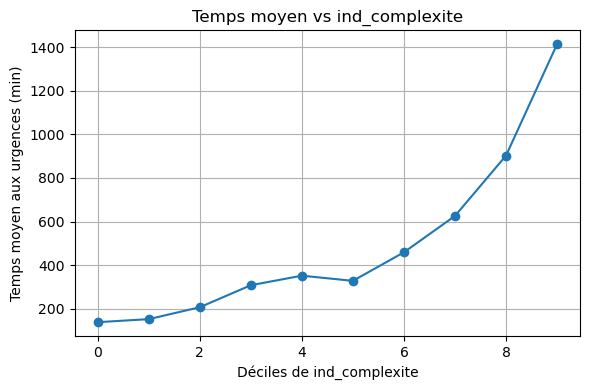


=== Résumé pour ind_chronicite_delais ===
   ind_chronicite_delais   mean  median  count  bin
0                      0 579.21  221.00  33626    0
1                      1 408.29  164.00  33627    1
2                      2 371.87  193.00  33623    2
3                      3 462.57  263.00  33625    3
4                      4 396.23  210.00  33626    4
5                      5 429.89  250.00  33625    5
6                      6 461.16  268.00  33625    6
7                      7 535.46  328.00  33625    7
8                      8 589.49  368.00  33625    8
9                      9 648.82  411.00  33626    9


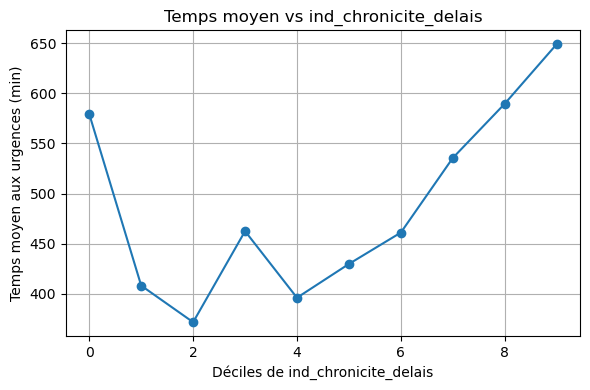


=== Résumé pour ind_issue ===
   ind_issue    mean  median  count  bin
0          0  316.97  156.50  33626    0
1          1  827.28  463.00  33625    1
2          2 1108.61  586.00  33625    2
3          3  160.49   88.00  33625    3
4          4  229.39  161.00  33626    4
5          5  336.65  261.00  33625    5
6          6  320.11  219.00  33625    6
7          7  346.66  235.00  33625    7
8          8  488.96  339.00  33625    8
9          9  747.90  459.50  33626    9


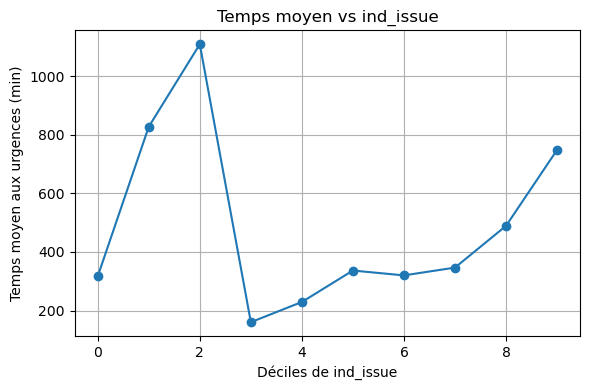


=== Résumé pour ind_congestion ===
   ind_congestion   mean  median  count  bin
0               0 577.48  328.00  33626    0
1               1 491.87  268.00  33625    1
2               2 454.25  239.00  33625    2
3               3 398.92  212.00  33625    3
4               4 385.29  197.00  33626    4
5               5 373.89  194.00  33627    5
6               6 372.05  204.00  33623    6
7               7 388.61  223.00  33625    7
8               8 537.76  328.00  33625    8
9               9 902.88  546.00  33626    9


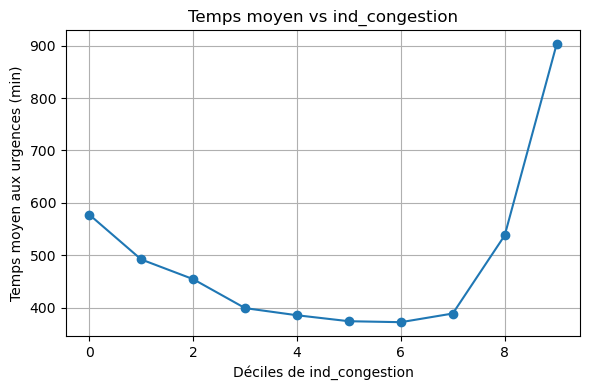


=== Résumé pour ind_specialisation_examens ===
   ind_specialisation_examens   mean  median  count  bin
0                           0 697.74  386.00  33626    0
1                           1 446.08  247.00  33625    1
2                           2 565.46  325.00  33625    2
3                           3 361.32  196.00  33625    3
4                           4 370.39  210.00  33626    4
5                           5 441.02  257.00  33625    5
6                           6 532.84  288.00  33625    6
7                           7 384.64  195.00  33625    7
8                           8 417.54  226.00  33625    8
9                           9 665.98  409.00  33626    9


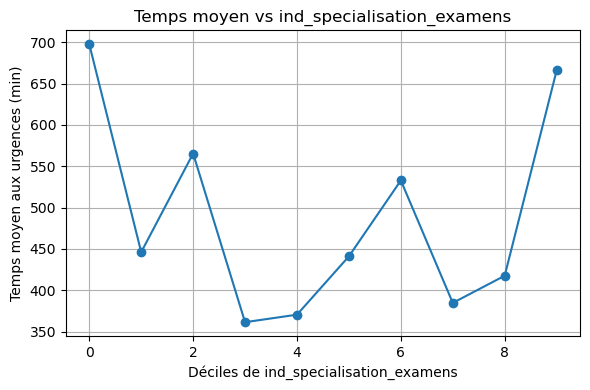

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

def courbe_indicateur(df, ind_col,
                      target_col='target_temps_urgences_minutes',
                      n_bins=10):
    # Déciles de l'indicateur
    bins = pd.qcut(df[ind_col], q=n_bins, labels=False, duplicates='drop')
    
    # Moyenne / médiane / effectifs
    summary = df.groupby(bins)[target_col].agg(['mean', 'median', 'count']).reset_index()
    summary.rename(columns={'index': 'bin'}, inplace=True)
    summary['bin'] = summary.index  # 0..n_bins-1
    
    print(f"\n=== Résumé pour {ind_col} ===")
    print(summary)
    
    # Courbe
    plt.figure(figsize=(6,4))
    plt.plot(summary['bin'], summary['mean'], marker='o')
    plt.xlabel(f'Déciles de {ind_col}')
    plt.ylabel('Temps moyen aux urgences (min)')
    plt.title(f'Temps moyen vs {ind_col}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return summary

# Lancer pour les 5 indicateurs
res_complexite = courbe_indicateur(df, 'ind_complexite')
res_chronicite = courbe_indicateur(df, 'ind_chronicite_delais')
res_issue = courbe_indicateur(df, 'ind_issue')
res_congestion = courbe_indicateur(df, 'ind_congestion')
res_specialisation = courbe_indicateur(df, 'ind_specialisation_examens')


### Analyse Tom

Dans cette partie, nous allons faire une analyse des variables creer par notre PCA, afin de comprendre ce que ces indices peuvent nous apporter dans la comprehension de la base de donnée.

### Interprétations 
PC1 augmente quand le patient est plus âgé, avec antécédents, a beaucoup d’examens (bio + imagerie, notamment scanner) et finit plus souvent en transfert plutôt qu’en retour direct à domicile
--> Indice de complexité de prise en charge / lourdeur du parcours

PC2 repère des patients polypathologiques (beaucoup d’antécédents, plutôt âgés) qui ont des délais plus longs avant entrée en box / PEC, mais sans forcément beaucoup d’imagerie lourde ni avis de spécialiste
--> Indice de chronicité et retard de prise en charge initiale

PC3 est quasiment un axe relié au type de sortie :
Valeurs positives : passages qui se terminent par un retour à domicile
Valeurs négatives : passages qui aboutissent à une hospitalisation ou un transfert
--> Indice d’issue du passage (domicile vs orientation lourde)

PC4 oppose des passages avec délais très longs avant box/PEC, arrivant plutôt à certaines heures (probablement heures chargées, en semaine), chez des patients moins marqués par les antécédents,
à des passages plus rapides, souvent le week-end ou chez des patients plus chroniques.
C’est un axe très organisationnel, qui traduit surtout la gestion des flux / congestion selon l’heure/jour.
--> Indice de congestion organisationnelle

PC5 distingue deux styles de prise en charge :
Côté positif : profils avec IRM + avis de spécialiste, souvent patients avec antécédents → imagerie plus pointue, plutôt spécialisée.
Côté négatif : imagerie plus standard (radio, échographie), souvent associée à des hospitalisations, avec moins d’IRM/avis spécialisés
--> Indice de spécialisation des examens

### Indicateur 1

PC1 augmente quand le patient est plus âgé, avec antécédents, a beaucoup d’examens (bio + imagerie, notamment scanner) et finit plus souvent en transfert plutôt qu’en retour direct à domicile
--> Indice de complexité de prise en charge / lourdeur du parcours

PC1 : Cet indicateur semble etre le plus important de tous, il indique le temps que passe un patient au urgence en fonction de ses antecedants, et de son age.

 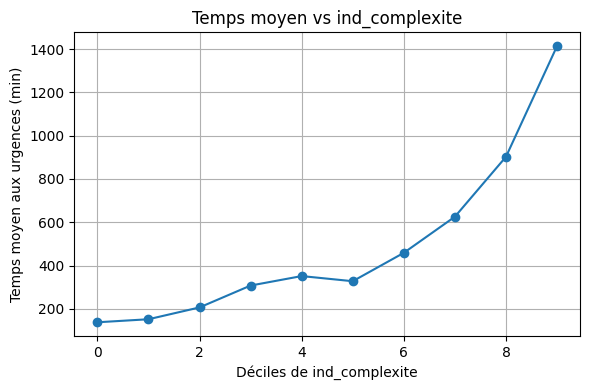

 On voit sur ce graphique qui represente le temps passé dans le service des urgences en fonctions de l'indice de complexité d'un patient. Plus cette indice augmente, plus le temps passé dans le service est long. A noté que ce temps augmente fortement lorsque cet indice passe a dela de 6.

 Il fait sens qu'un patient avec des anteecedants peu avantageux et/ou avec un age avancé passe potentielement plus de temps au urgence, etant donne le lot d'examen plus lourd et long qui doit etre fait

 Qui dit plus d'examen dit plus de temps au urgence, plus de personne impliqué dans la prise en charge de ce patient, cette indicateur a donc tout son interret dans cette etude.

 --> ce qu'il fait retenir : un patient ayant un certain age, combiné a des antecedants medicaux, va alors passe plus de temps dans le service et donc attendre beaucoup, en sachant cela, adapter sa strategie de soin ou d'organisation peut etre pertinent afin d'optimiser le temps d'attente de tous les patients du service.

In [37]:
# Les courbes

In [38]:
# Analyse

In [39]:
# Intérêt de l’étude

### Indicateur 2

In [40]:
# Les courbes

In [41]:
# Analyse

In [42]:
# Intérêt de l'étude

### Indicateur 3

In [43]:
# Les courbes

In [44]:
# Analyse

In [45]:
# Intérêt de l'étude

# II.2. Apprentissage et prédiction

## II.2.1. Prédiction de la loi d’arrivée des patients aux SUA

analyse descriptive (ce qui s'est passé) --> une analyse prédictive (ce qui va arriver)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 316901 entries, 0 to 336252
Data columns (total 88 columns):
 #   Column                                                                        Non-Null Count   Dtype         
---  ------                                                                        --------------   -----         
 0   num_dordre                                                                    316901 non-null  int64         
 1   date                                                                          316901 non-null  datetime64[ns]
 2   heure                                                                         316901 non-null  object        
 3   _informations_du_passage_date_et_heure_darrive                                316901 non-null  datetime64[ns]
 4   _informations_du_passage_moyen_darrive                                        315616 non-null  object        
 5   _iao_motif_dentre                                                             295648

In [46]:
df.head()

,num_dordre,date,heure,_informations_du_passage_date_et_heure_darrive,_informations_du_passage_moyen_darrive,_iao_motif_dentre,_iao_motif_de_venue,_patient_age_en_anne,_antcdent_antcdents_mdicaux,_antcdent_antcdents_chirurgicaux,_constante_surveillances_paspad_adultes_premire_valeur,_constante_surveillances_fc_adultes_premire_valeur,_constante_surveillances_temprature_adultes_premire_valeur,_constante_surveillances_sao2_adultes_premire_valeur,_constante_surveillances_frquence_respiratoire_premire_valeur,_diagnostic_code_ccmu,_localisation_salles,_localisation_date_dentre_en_box,_anamnse_texte,_iao_observation,_examens_complmentaires_a_des_examens_de_biologie,_examens_complmentaires_a_des_examens_de_radiologie,_examens_complmentaires_a_des_examens_dchographie,_examens_complmentaires_a_des_examens_de_scanner,_examens_complmentaires_a_des_examens_dirm,_examens_complmentaires_a_des_avis_de_spcialistes,_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie,_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie,_diagnostic_diagnostic_principal_code_diagnostic,_diagnostic_diagnostic_principal_intitul,_informations_du_passage_cac_dadmission,_informations_du_passage_cac_du_sjour,_informations_du_passage_date_et_heure_de_sortie,_informations_du_passage_date_dbut_prise_en_charge_mdicale,_orientation_type_dorientation,_orientation_destination,_orientation_tansfert_vers_le_service,_orientation_transfert_vers_lhpital,_patient_code_postal_de_la_ville,_patient_nom_de_la_ville,target_temps_urgences_minutes,heure_arrivee,pas,pad,fc,temperature,sao2,fr,_localisation_date_dentre_en_box_dt,_examens_complmentaires_date_et_heure_de_premire_prescription_de_biologie_dt,_examens_complmentaires_date_et_heure_de_premier_prlvement_de_biologie_dt,_informations_du_passage_date_dbut_prise_en_charge_mdicale_dt,datetime_arrivee,datetime_sortie,delai_total_calc,diff_target_delai,delai_arrivee_PEC,delai_arrivee_box,jour_semaine,is_weekend,_examens_complmentaires_a_des_examens_de_biologie_01,_examens_complmentaires_a_des_examens_de_radiologie_01,_examens_complmentaires_a_des_examens_dchographie_01,_examens_complmentaires_a_des_examens_de_scanner_01,_examens_complmentaires_a_des_examens_dirm_01,_examens_complmentaires_a_des_avis_de_spcialistes_01,exam_bio,exam_radio,exam_echo,exam_scanner,exam_irm,avis_specialiste,nb_exam_imagerie,score_ressources,has_ant_med,has_ant_chir,is_retour_domicile,is_transfert,is_hospit,delai_arrivee_PEC_cap,delai_arrivee_box_cap,ind_complexite,ind_chronicite_delais,ind_issue,ind_congestion,ind_specialisation_examens
0,1,2016-06-01,00:16:00,2016-06-01 00:16:00,AMBULANCE PRIVEE,"Malaise, difficulté respi, palpitation, Pas de...",Cardiologie: Palpitations Malaise,33,NaN,NaN,110/56,52,34.90,97,NaN,1,"((Attente pré IOA,01/06/2016 00:16,01/06/2016 ...",42522.05,MDC: Dyspnée aiguë et palpitations ATCDS: ...,NaN,oui,oui,non,non,non,non,42522.06,42522.07,R06.0,Dyspnée,ACCUEIL SURVEILLANCE ET ADMISSION URGENCE ADUL...,3093.00,2016-06-01 04:14:00.000001271,42522.04,RETOUR DOMICILE,RETOUR DOMICILE,NaN,NaN,59139,WATTIGNIES,238.00,0,110.00,56.00,52.00,34.90,97.00,NaN,2016-06-01 01:05:59.999997189,2016-06-01 01:30:00.000000000,2016-06-01 01:34:59.999997838,2016-06-01 01:02:59.999999749,2016-06-01 00:16:00,2016-06-01 04:14:00.000001271,238.00,0.00,47.00,50.00,2,0,1,1,0,0,0,0,1,1,0,0,0,0,1,2,0,0,1,0,0,47.00,50.00,0.12,-1.09,1.31,-1.86,-0.62
1,2,2016-06-01,00:18:00,2016-06-01 00:18:00,AMBULANCE PRIVEE,"AEG, Hyperthermie et difficulté respi en maiso...",Maladies infectieuses: Hyperthermie,78,NaN,NaN,90/41,77,36.30,98,NaN,2,"((Attente pré IOA,01/06/2016 00:18,01/06/2016 ...",42522.06,vient pour hyperthermie ATCD: DID retard ...,NaN,oui,oui,non,non,non,non,42522.07,42522.07,R50.9,"Fièvre, sans précision",ACCUEIL SURVEILLANCE ET ADMISSION URGENCE ADUL...,3102.00,2016-06-01 11:05:00.000003701,42522.09,TRANSFERT EXTERNE,Transfert CLINIQUE DUBOIS (LILLE) Motif: Conve...,NaN,CLINIQUE DUBOIS,59310,ORCHIES,647.00,0,90.00,41.00,77

base de données individuelle (un patient par ligne) à une série temporelle agrégée par heure via la fonction resample.

In [47]:
# On s'assure que la colonne est bien au format datetime
df['_informations_du_passage_date_et_heure_darrive'] = pd.to_datetime(df['_informations_du_passage_date_et_heure_darrive'])

# Création d'un nouveau DataFrame agrégé par heure
df_flux = df.resample('H', on='_informations_du_passage_date_et_heure_darrive').size().reset_index()
df_flux.columns = ['date_heure', 'nb_arrivees']

df_flux.head()

/var/folders/rz/t_ljsb4j549f050tl88tfp2c0000gn/T/ipykernel_20082/2418839774.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_flux = df.resample('H', on='_informations_du_passage_date_et_heure_darrive').size().reset_index()


,date_heure,nb_arrivees
0,2016-06-01 00:00:00,4
1,2016-06-01 01:00:00,5
2,2016-06-01 02:00:00,3
3,2016-06-01 03:00:00,1
4,2016-06-01 04:00:00,4


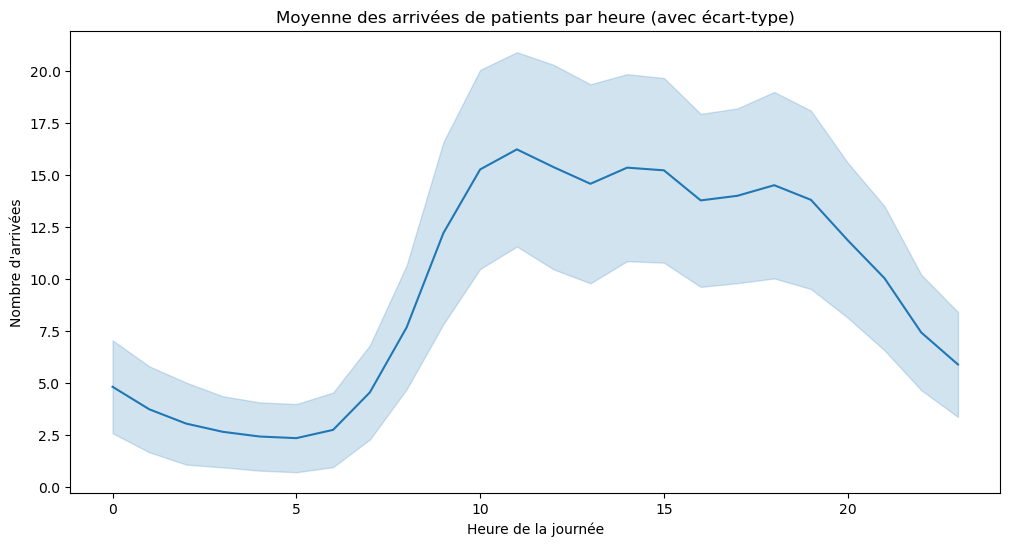

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout de variables temporelles pour l'analyse
df_flux['heure'] = df_flux['date_heure'].dt.hour
df_flux['jour_semaine'] = df_flux['date_heure'].dt.day_name()

# Visualisation de la moyenne d'arrivées par heure de la journée
plt.figure(figsize=(12,6))
sns.lineplot(data=df_flux, x='heure', y='nb_arrivees', errorbar='sd')
plt.title("Moyenne des arrivées de patients par heure (avec écart-type)")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre d'arrivées")
plt.show()

In [49]:
moyenne = df_flux['nb_arrivees'].mean()
variance = df_flux['nb_arrivees'].var()

print(f"Moyenne : {moyenne:.2f}")
print(f"Variance : {variance:.2f}")

Moyenne : 9.58
Variance : 39.11


En théorie, si les arrivées suivaient une Loi de Poisson parfaite (très utilisée pour modéliser les flux), la moyenne devrait être égale à la variance.

Ici, la variance est environ 4 fois supérieure à la moyenne.

-> : surdispersion. arrivées pas régulières. -> moments de grand calme et des moments de pics très intenses

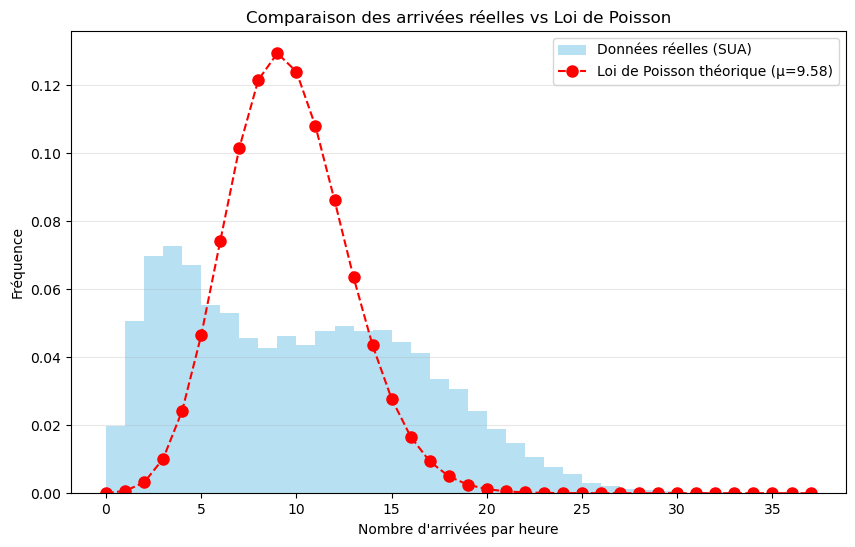

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 1. Préparation des données pour l'histogramme
data = df_flux['nb_arrivees']
bins = np.arange(0, data.max() + 1)

# 2. Création du graphique
plt.figure(figsize=(10, 6))
# Histogramme des données réelles
plt.hist(data, bins=bins, density=True, alpha=0.6, color='skyblue', label='Données réelles (SUA)')

# 3. Tracé de la loi de Poisson théorique (avec ta moyenne de 9.58)
mu = 9.58
x = np.arange(0, data.max() + 1)
plt.plot(x, poisson.pmf(x, mu), 'ro--', ms=8, label=f'Loi de Poisson théorique (μ={mu})')

plt.title('Comparaison des arrivées réelles vs Loi de Poisson')
plt.xlabel('Nombre d\'arrivées par heure')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [51]:
# On repart de notre DataFrame 'df_flux' créé précédemment
df_ml = df_flux.copy()

# Extraction des caractéristiques temporelles
df_ml['heure'] = df_ml['date_heure'].dt.hour
df_ml['jour_semaine'] = df_ml['date_heure'].dt.dayofweek # 0=Lundi, 6=Dimanche
df_ml['mois'] = df_ml['date_heure'].dt.month
df_ml['est_weekend'] = df_ml['jour_semaine'].apply(lambda x: 1 if x >= 5 else 0)

# On affiche les premières lignes pour vérifier
print(df_ml.head())

           date_heure  nb_arrivees  heure  jour_semaine  mois  est_weekend
0 2016-06-01 00:00:00            4      0             2     6            0
1 2016-06-01 01:00:00            5      1             2     6            0
2 2016-06-01 02:00:00            3      2             2     6            0
3 2016-06-01 03:00:00            1      3             2     6            0
4 2016-06-01 04:00:00            4      4             2     6            0


La création de variables (Features) : L'ordinateur ne comprend pas une date comme "Lundi 12 Juin 14h". Nous avons décomposé la date en chiffres :

L'heure (0-23) : Pour capter les pics de journée.

Le jour de la semaine (0-6) : Pour capter l'effet "week-end" (souvent plus chargé car les médecins de ville sont fermés).

Le mois : Pour capter la saisonnalité (grippes en hiver, par exemple).

In [52]:
from sklearn.model_selection import train_test_split

# Variables explicatives (X) et cible à prédire (y)
X = df_ml[['heure', 'jour_semaine', 'mois', 'est_weekend']]
y = df_ml['nb_arrivees']

# split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'entraînement : {len(X_train)} heures")
print(f"Taille du test : {len(X_test)} heures")

Taille de l'entraînement : 28070 heures
Taille du test : 7018 heures


In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Création et entraînement du modèle
modele = LinearRegression()
modele.fit(X_train, y_train)

# Prédiction sur les données de test
y_pred = modele.predict(X_test)

# Évaluation du modèle
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur moyenne (MAE) : {mae:.2f} patients")
print(f"Précision (R2 Score) : {r2:.2f}")

Erreur moyenne (MAE) : 4.42 patients
Précision (R2 Score) : 0.24


La Régression Linéaire ($R^2 = 0,24$)Le concept : Elle cherche à tracer une ligne droite au milieu des points.Pourquoi l'échec ? La fréquentation des urgences n'est pas une ligne droite. Elle monte et descend (vagues). La régression linéaire est incapable de comprendre qu'à 14h c'est plein et qu'à 4h c'est vide si elle essaie de tout relier par une droite.

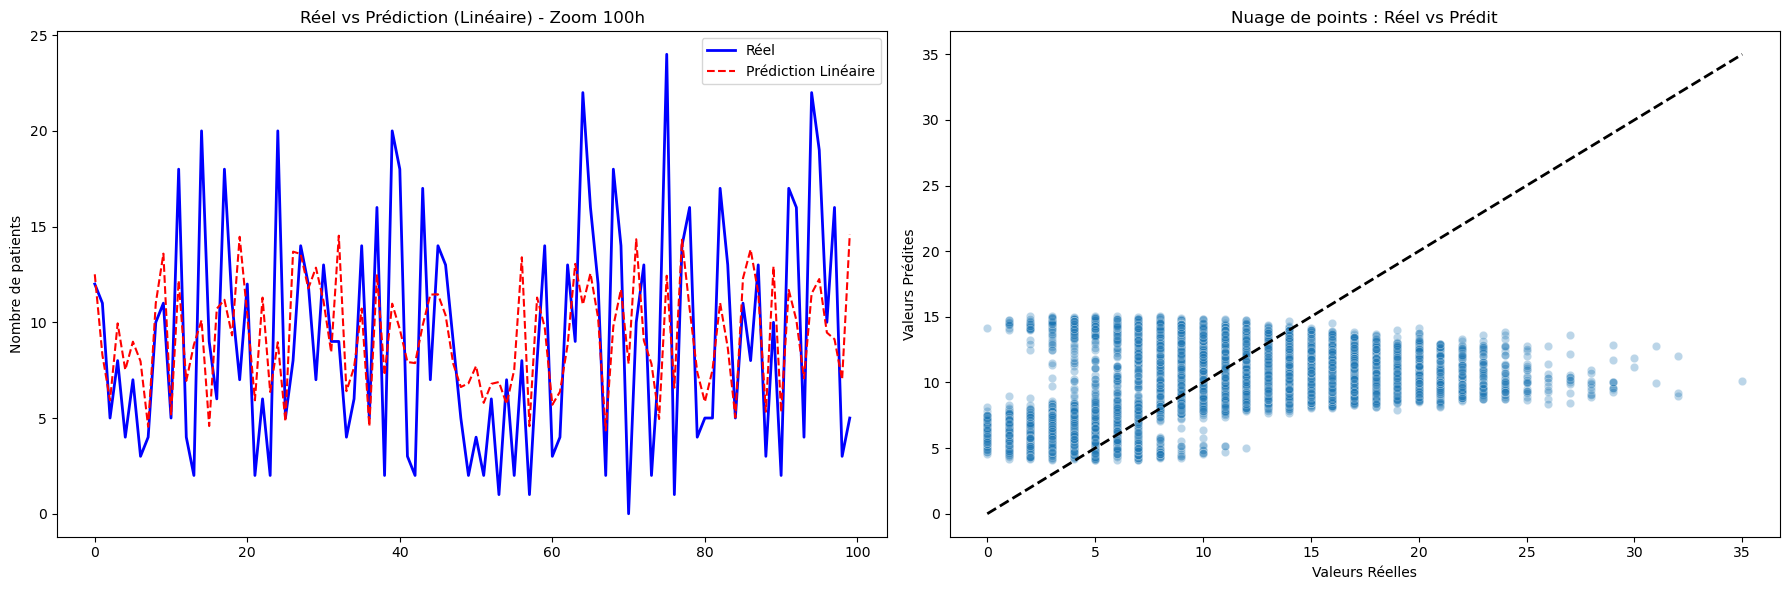

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prédiction sur l'ensemble du jeu de test
y_pred_lin = modele.predict(X_test)

# 2. Création de la figure
plt.figure(figsize=(18, 6))

# --- GRAPHIQUE 1 : Comparaison temporelle (zoom sur 100 heures) ---
plt.subplot(1, 2, 1)
plt.plot(y_test.values[:100], label='Réel', color='blue', linewidth=2)
plt.plot(y_pred_lin[:100], label='Prédiction Linéaire', color='red', linestyle='--')
plt.title("Réel vs Prédiction (Linéaire) - Zoom 100h")
plt.legend()
plt.ylabel("Nombre de patients")

# --- GRAPHIQUE 2 : Corrélation ---
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_lin, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ligne idéale
plt.title("Nuage de points : Réel vs Prédit")
plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")

plt.tight_layout()
plt.show()

In [55]:
from sklearn.ensemble import RandomForestRegressor

# 1. Création du modèle Random Forest
# n_estimators=100 signifie qu'on utilise 100 arbres de décision pour voter
rf_modele = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entraînement
rf_modele.fit(X_train, y_train)

# 3. Prédiction et évaluation
y_pred_rf = rf_modele.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"--- RÉSULTATS RANDOM FOREST ---")
print(f"Nouvelle erreur moyenne (MAE) : {mae_rf:.2f} patients")
print(f"Nouveau score de précision (R2) : {r2_rf:.2f}")

--- RÉSULTATS RANDOM FOREST ---
Nouvelle erreur moyenne (MAE) : 2.67 patients
Nouveau score de précision (R2) : 0.68


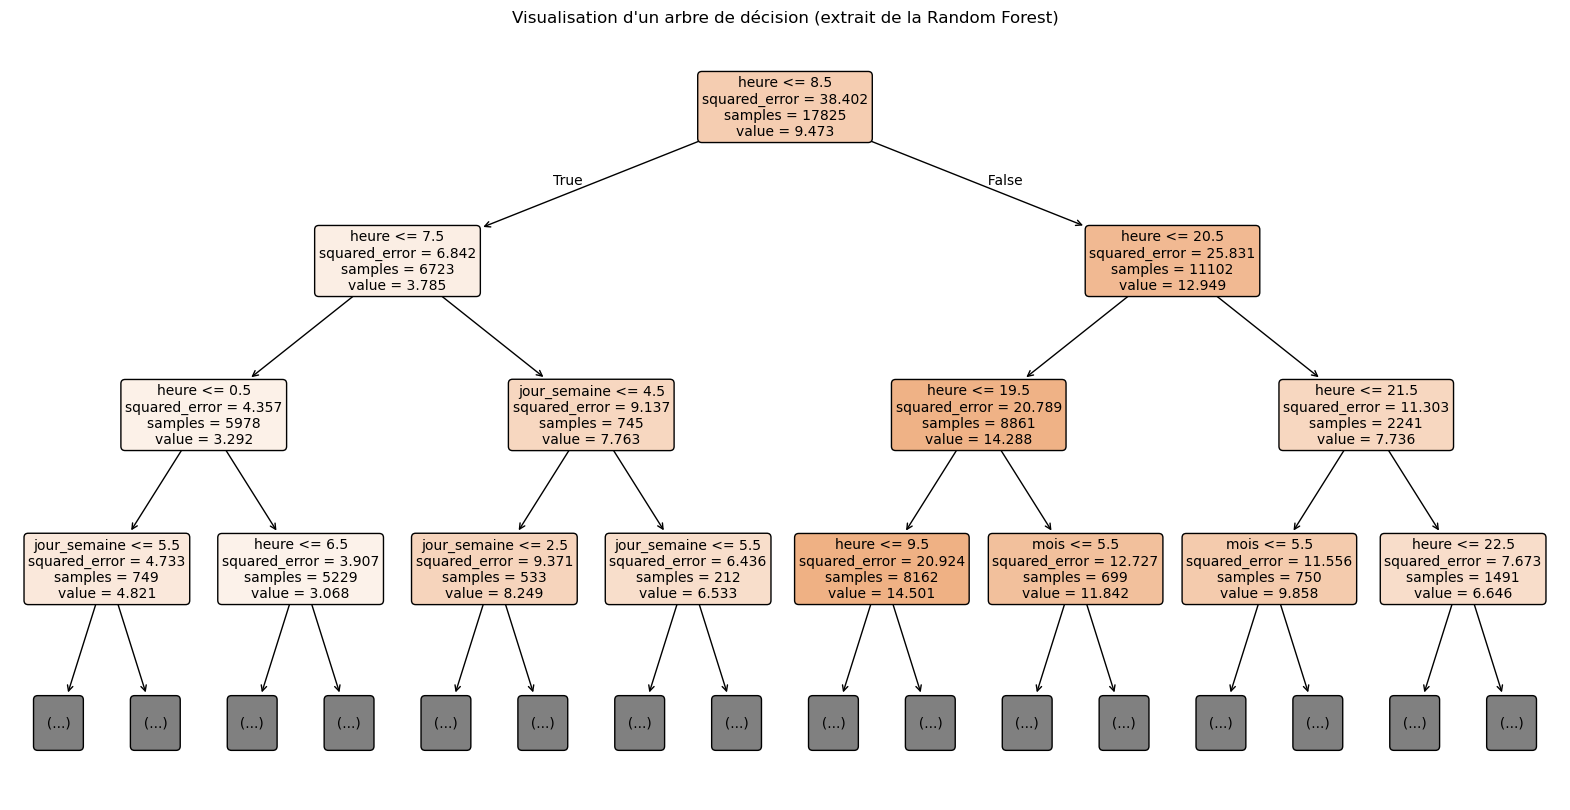

In [56]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# On choisit l'un des arbres de la forêt (le premier, indice 0)
arbre_a_afficher = rf_modele.estimators_[0]

# Création de la figure
plt.figure(figsize=(20, 10))

# Affichage de l'arbre
# On limite la profondeur à 3 niveaux (max_depth=3) pour que ce soit lisible
# Sinon l'image sera trop grande et illisible
plot_tree(arbre_a_afficher, 
          feature_names=['heure', 'jour_semaine', 'mois', 'est_weekend'],
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) 

plt.title("Visualisation d'un arbre de décision (extrait de la Random Forest)")
plt.show()

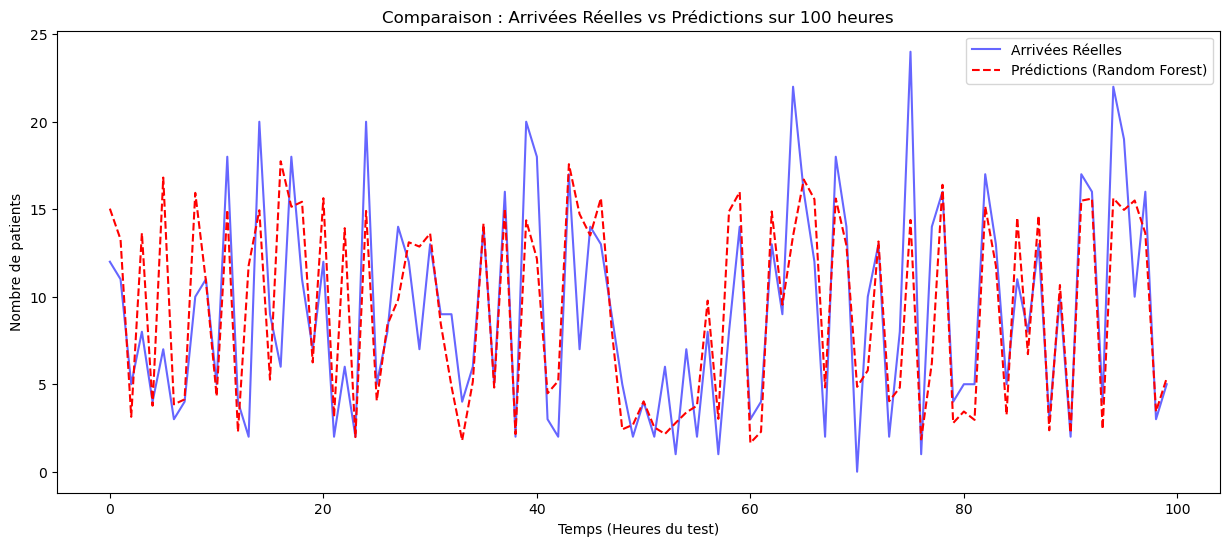

In [57]:
plt.figure(figsize=(15, 6))

# On prend les 100 premières heures du jeu de test pour que le graphique soit lisible
plt.plot(y_test.values[:100], label='Arrivées Réelles', color='blue', alpha=0.6)
plt.plot(y_pred_rf[:100], label='Prédictions (Random Forest)', color='red', linestyle='--')

plt.title("Comparaison : Arrivées Réelles vs Prédictions sur 100 heures")
plt.xlabel("Temps (Heures du test)")
plt.ylabel("Nombre de patients")
plt.legend()
plt.show()

 Analyse des résultats (Section II.2.1.2)Tu peux expliquer la différence entre les deux modèles :Performance : Avec un $R^2$ de 0,68, ton modèle explique désormais 68 % de la variabilité des arrivées. C'est un score très solide pour des données humaines et hospitalières, qui comportent toujours une part d'aléa (urgences imprévisibles).Précision : L'erreur moyenne (MAE) est tombée à 2,67 patients. Cela signifie qu'en moyenne, ta prédiction ne se trompe que de 2 ou 3 personnes par heure. Pour un gestionnaire de flux, c'est une marge d'erreur très acceptable pour prévoir les ressources.Pourquoi ça marche mieux ? Contrairement à la régression linéaire, le Random Forest est capable de comprendre que "11h du matin" est un pic alors que "4h du matin" est un creux, sans que la relation soit une ligne droite.2. 
 
 
 Intérêt de l'étude (Section II.2.1.3)C'est ici que tu valorises ton travail pour l'optimisation des urgences :Planification RH : En prédisant avec 68 % de fiabilité le flux à venir, la direction peut ajuster le nombre d'infirmiers au "Triage" (IOA). Si le modèle prévoit un pic à 14h, on peut s'assurer que l'équipe est complète à ce moment-là.Réduction de l'attente : Anticiper l'arrivée des patients permet de préparer les box d'examen avant que la salle d'attente ne déborde, limitant ainsi le risque de saturation (congestion).Aide à la décision : Ce modèle sert d'outil de "météo des urgences" pour le cadre de santé.

ducoup pour ma soutenance, je peux proposer ce genre de modele au service des urgences afin de savoir quand mettre du personnel par exemple?

Absolument ! C'est d'ailleurs l'aboutissement logique de ton projet. En présentant cela lors de ta soutenance, tu ne montres pas seulement que tu sais coder, mais que tu apportes une solution concrète à un problème de gestion hospitalière.Voici comment tu peux "vendre" cette idée dans ta présentation :1. Passer du "Subir" à l'"Anticiper"Actuellement, beaucoup de services d'urgences fonctionnent en réaction : on appelle du renfort quand la salle d'attente est déjà pleine.Ton modèle permet une approche proactive : Si l'algorithme prévoit un pic de 15 patients à 14h, le cadre de santé peut décider dès le matin de doubler l'effectif à l'IOA (Infirmier Organisateur de l'Accueil) pour fluidifier le tri.2. Les bénéfices concrets pour le serviceTu peux structurer cet argumentaire en trois points clés :Optimisation des Ressources Humaines : Éviter le sous-effectif pendant les pics (qui génère du stress et des erreurs) et le sur-effectif pendant les creux (qui coûte cher inutilement).Réduction du temps d'attente : En anticipant le flux, on réduit le "goulot d'étranglement" au triage.Amélioration de la Qualité des Soins : Un personnel bien dimensionné est un personnel qui peut consacrer plus de temps à chaque patient.3. Les limites à mentionner (pour montrer ton esprit critique)Pour être crédible face à un jury, il faut admettre qu'un modèle n'est pas une boule de cristal :L'imprévisible : Ton modèle (avec un $R^2$ de 0,68) prédit très bien la "routine" (les cycles sociaux), mais il ne peut pas prédire un accident de bus ou une catastrophe majeure.La "Météo des Urgences" : Tu devrais présenter ton outil comme une aide à la décision pour le cadre de santé, et non comme un remplaçant de son expertise.

avant de passer a la suite, explique moi pourquoi on utilise pas des modeles comme SARIMA qui utilise notament la saisonalité, ca pourrait etre utile non? ou il y a un truc que jai oublie qui fait que cest pas tres bien ici

Gemini a dit
C'est une excellente question qui montre que tu as une très bonne intuition sur les séries temporelles. SARIMA (Seasonal AutoRegressive Integrated Moving Average) est effectivement le "standard d'or" de la statistique classique pour la prédiction saisonnière.

Tu n'as rien "oublié", mais il y a des raisons techniques et stratégiques pour lesquelles on privilégie souvent le Random Forest (ou le Machine Learning) dans un projet comme le tien.

Voici pourquoi SARIMA peut être plus difficile, voire "moins bon" dans ce cas précis :

1. La complexité des paramètres (Le "tuning")
SARIMA demande de régler 7 paramètres (p,d,q) x (P,D,Q,s).

La saisonnalité multiple : Aux urgences, tu as une double (voire triple) saisonnalité : journalière (24h) et hebdomadaire (7 jours). SARIMA classique a du mal à gérer deux cycles en même temps. Il faut souvent choisir l'un ou l'autre, ce qui fait perdre de la précision.

Random Forest : Il s'en moque. Tu lui donnes une colonne "Heure" et une colonne "Jour", et il comprend tout seul les deux cycles sans réglage complexe.

2. La sensibilité au "Bruit" et aux valeurs manquantes
Les arrivées aux urgences sont très stochastiques (aléatoires). Comme tu l'as vu, ta variance est élevée (39,11).

SARIMA : C'est un modèle "rigide" qui repose sur l'idée que le futur est une combinaison linéaire du passé. S'il y a un pic soudain ou un trou dans les données, cela peut déstabiliser tout le modèle.

Random Forest : C'est un modèle "robuste". Comme il fonctionne par arbres de décision, il est beaucoup moins perturbé par les valeurs extrêmes ou les bruits bizarres dans les données.

3. L'intégration de variables externes (Exogènes)
C'est l'argument majeur pour ton projet.

SARIMA : Pour ajouter des variables comme "Jour férié", "Vacances scolaires" ou "Météo", il faut passer à un modèle encore plus complexe appelé SARIMAX.

Random Forest : Il suffit d'ajouter une colonne dans ton tableau X. C'est extrêmement simple d'enrichir le modèle pour le rendre plus intelligent.

4. L'interprétation pour la soutenance
Pour un projet "Fil Rouge" ou une soutenance :

Expliquer le fonctionnement d'un Arbre de Décision est très visuel et facile à comprendre pour un jury ("Si il est 10h et que c'est lundi, alors...").

Expliquer les équations de différenciation et d'autocorrélation de SARIMA est beaucoup plus lourd mathématiquement et peut te piéger si on te pose des questions pointues sur la "stationnarité".



=== STATISTIQUES DE BASE ===
count   1462.00
mean     216.76
std       28.14
min       90.00
25%      206.00
50%      220.00
75%      233.00
max      303.00
Name: nb_arrivees, dtype: float64

Période couverte : 2016-06-01 00:00:00 → 2020-06-01 00:00:00

=== TEST LOI D'ARRIVÉE ===
Moyenne journalière : 216.8 patients/jour
Variance            : 792.1
Ratio variance/moyenne (dispersion) : 3.65
→ Si ratio ≈ 1 : loi de Poisson adaptée
→ Si ratio >> 1 : surdispersion → Negative Binomiale recommandée

Test KS Poisson : stat=0.1412, p-value=0.0000
❌ Loi de Poisson rejetée → tester Negative Binomiale


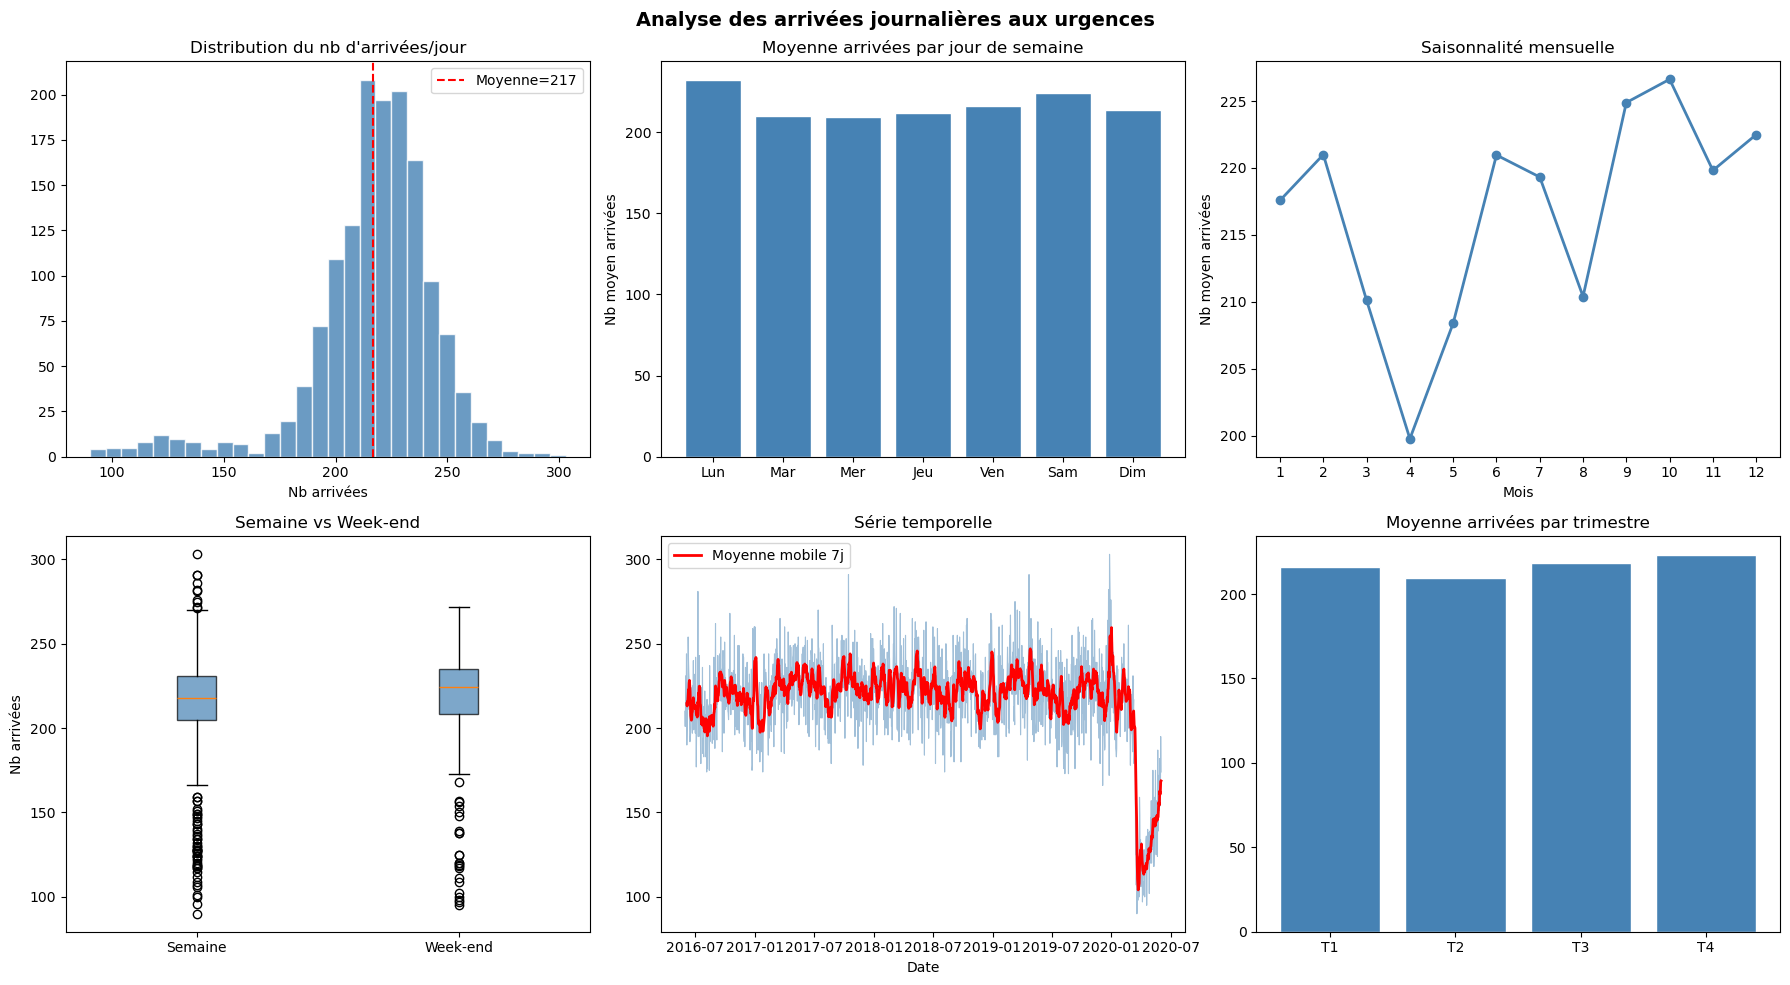


=== TESTS STATISTIQUES ===
Kruskal-Wallis (jour semaine) : stat=206.79, p=0.0000 ✅ Significatif
Mann-Whitney (semaine/weekend) : stat=193027.00, p=0.0006 ✅ Significatif
Kruskal-Wallis (mois)         : stat=58.01, p=0.0000 ✅ Significatif
Kruskal-Wallis (trimestre)    : stat=11.06, p=0.0114 ✅ Significatif


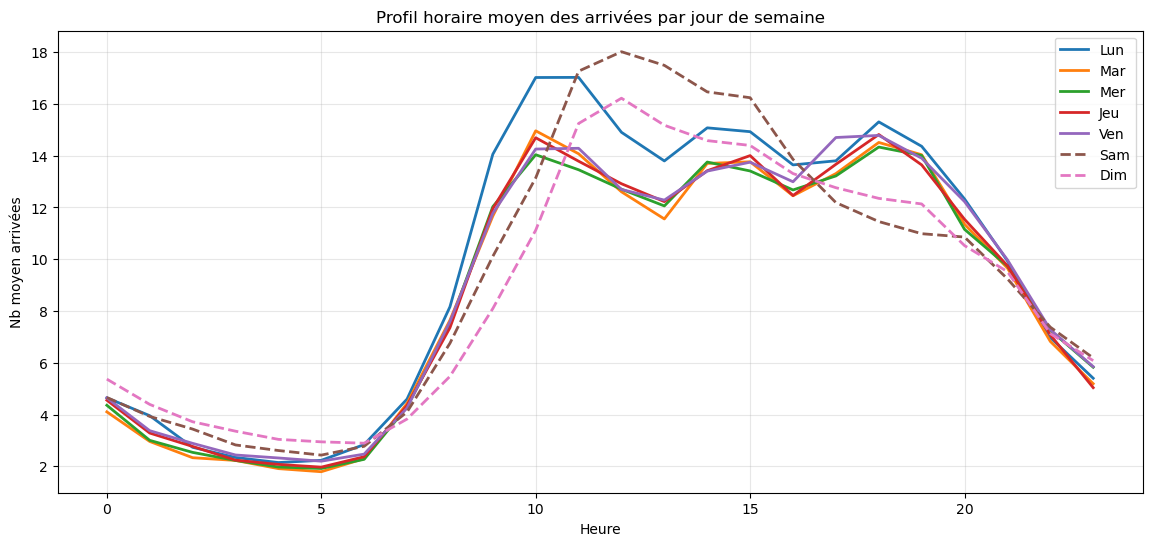


✅ Analyse terminée — 2 graphiques sauvegardés


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, nbinom, kstest
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. AGREGATION JOURNALIERE
# ============================================================

df_daily = df.groupby('date').size().reset_index(name='nb_arrivees')
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily['jour_semaine'] = df_daily['date'].dt.dayofweek      # 0=Lundi
df_daily['is_weekend']   = df_daily['jour_semaine'].isin([5,6]).astype(int)
df_daily['mois']         = df_daily['date'].dt.month
df_daily['annee']        = df_daily['date'].dt.year
df_daily['semaine']      = df_daily['date'].dt.isocalendar().week.astype(int)
df_daily['trimestre']    = df_daily['date'].dt.quarter

print("=== STATISTIQUES DE BASE ===")
print(df_daily['nb_arrivees'].describe())
print(f"\nPériode couverte : {df_daily['date'].min()} → {df_daily['date'].max()}")

# ============================================================
# 2. TEST DE LA LOI DE POISSON & NEGATIVE BINOMIALE
# ============================================================

mu = df_daily['nb_arrivees'].mean()
var = df_daily['nb_arrivees'].var()
print(f"\n=== TEST LOI D'ARRIVÉE ===")
print(f"Moyenne journalière : {mu:.1f} patients/jour")
print(f"Variance            : {var:.1f}")
print(f"Ratio variance/moyenne (dispersion) : {var/mu:.2f}")
print("→ Si ratio ≈ 1 : loi de Poisson adaptée")
print("→ Si ratio >> 1 : surdispersion → Negative Binomiale recommandée")

# Test KS pour Poisson
ks_stat, ks_pval = kstest(
    df_daily['nb_arrivees'], 
    'poisson', 
    args=(mu,)
)
print(f"\nTest KS Poisson : stat={ks_stat:.4f}, p-value={ks_pval:.4f}")
if ks_pval > 0.05:
    print("✅ Loi de Poisson non rejetée (p > 0.05)")
else:
    print("❌ Loi de Poisson rejetée → tester Negative Binomiale")

# ============================================================
# 3. ANALYSE EXPLORATOIRE — VARIABLES SIGNIFICATIVES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Analyse des arrivées journalières aux urgences", fontsize=14, fontweight='bold')

# 3.1 Distribution globale
axes[0,0].hist(df_daily['nb_arrivees'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(mu, color='red', linestyle='--', label=f'Moyenne={mu:.0f}')
axes[0,0].set_title("Distribution du nb d'arrivées/jour")
axes[0,0].set_xlabel("Nb arrivées"); axes[0,0].legend()

# 3.2 Par jour de semaine
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
moy_jour = df_daily.groupby('jour_semaine')['nb_arrivees'].mean()
axes[0,1].bar(jours, moy_jour.values, color='steelblue', edgecolor='white')
axes[0,1].set_title("Moyenne arrivées par jour de semaine")
axes[0,1].set_ylabel("Nb moyen arrivées")

# 3.3 Par mois
moy_mois = df_daily.groupby('mois')['nb_arrivees'].mean()
axes[0,2].plot(moy_mois.index, moy_mois.values, marker='o', color='steelblue', linewidth=2)
axes[0,2].set_title("Saisonnalité mensuelle")
axes[0,2].set_xlabel("Mois"); axes[0,2].set_ylabel("Nb moyen arrivées")
axes[0,2].set_xticks(range(1,13))

# 3.4 Semaine vs Weekend
weekend_data = [
    df_daily[df_daily['is_weekend']==0]['nb_arrivees'],
    df_daily[df_daily['is_weekend']==1]['nb_arrivees']
]
axes[1,0].boxplot(weekend_data, labels=['Semaine', 'Week-end'], patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1,0].set_title("Semaine vs Week-end")
axes[1,0].set_ylabel("Nb arrivées")

# 3.5 Série temporelle
axes[1,1].plot(df_daily['date'], df_daily['nb_arrivees'], alpha=0.5, color='steelblue', linewidth=0.8)
rolling = df_daily['nb_arrivees'].rolling(7).mean()
axes[1,1].plot(df_daily['date'], rolling, color='red', linewidth=2, label='Moyenne mobile 7j')
axes[1,1].set_title("Série temporelle")
axes[1,1].set_xlabel("Date"); axes[1,1].legend()

# 3.6 Par trimestre
moy_trim = df_daily.groupby('trimestre')['nb_arrivees'].mean()
axes[1,2].bar(['T1','T2','T3','T4'], moy_trim.values, color='steelblue', edgecolor='white')
axes[1,2].set_title("Moyenne arrivées par trimestre")

plt.tight_layout()
plt.savefig("arrivees_analyse.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. TESTS STATISTIQUES DE SIGNIFICATIVITÉ
# ============================================================

print("\n=== TESTS STATISTIQUES ===")

# Kruskal-Wallis : jour de semaine
groupes_jour = [df_daily[df_daily['jour_semaine']==j]['nb_arrivees'].values for j in range(7)]
stat, p = stats.kruskal(*groupes_jour)
print(f"Kruskal-Wallis (jour semaine) : stat={stat:.2f}, p={p:.4f} {'✅ Significatif' if p<0.05 else '❌ Non significatif'}")

# Mann-Whitney : semaine vs weekend
stat, p = stats.mannwhitneyu(
    df_daily[df_daily['is_weekend']==0]['nb_arrivees'],
    df_daily[df_daily['is_weekend']==1]['nb_arrivees']
)
print(f"Mann-Whitney (semaine/weekend) : stat={stat:.2f}, p={p:.4f} {'✅ Significatif' if p<0.05 else '❌ Non significatif'}")

# Kruskal-Wallis : mois
groupes_mois = [df_daily[df_daily['mois']==m]['nb_arrivees'].values for m in range(1,13)]
stat, p = stats.kruskal(*groupes_mois)
print(f"Kruskal-Wallis (mois)         : stat={stat:.2f}, p={p:.4f} {'✅ Significatif' if p<0.05 else '❌ Non significatif'}")

# Kruskal-Wallis : trimestre
groupes_trim = [df_daily[df_daily['trimestre']==t]['nb_arrivees'].values for t in range(1,5)]
stat, p = stats.kruskal(*groupes_trim)
print(f"Kruskal-Wallis (trimestre)    : stat={stat:.2f}, p={p:.4f} {'✅ Significatif' if p<0.05 else '❌ Non significatif'}")

# ============================================================
# 5. PROFIL HORAIRE PAR JOUR (pour dimensionnement ressources)
# ============================================================

df['heure'] = pd.to_datetime(df['datetime_arrivee']).dt.hour
df['jour_semaine_arr'] = pd.to_datetime(df['datetime_arrivee']).dt.dayofweek

profil = df.groupby(['jour_semaine_arr', 'heure']).size().reset_index(name='nb')
profil_pivot = profil.pivot(index='heure', columns='jour_semaine_arr', values='nb')
profil_pivot.columns = jours

# Normaliser par nb de semaines pour avoir une moyenne
n_semaines = len(df_daily) / 7
profil_pivot_moy = profil_pivot / n_semaines

fig, ax = plt.subplots(figsize=(14, 6))
for jour in jours:
    style = '--' if jour in ['Sam', 'Dim'] else '-'
    ax.plot(profil_pivot_moy.index, profil_pivot_moy[jour], label=jour, linewidth=2, linestyle=style)
ax.set_title("Profil horaire moyen des arrivées par jour de semaine")
ax.set_xlabel("Heure"); ax.set_ylabel("Nb moyen arrivées")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig("profil_horaire.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Analyse terminée — 2 graphiques sauvegardés")

In [75]:
# ============================================================
# FEATURES AGRÉGÉES AU NIVEAU JOUR
# ============================================================

df['date_only'] = pd.to_datetime(df['datetime_arrivee']).dt.date

agg_daily = df.groupby('date_only').agg(
    nb_arrivees        = ('num_dordre', 'count'),
    
    # Mix de patients (composition du flux)
    age_moyen          = ('_patient_age_en_anne', 'mean'),
    pct_hospit         = ('is_hospit', 'mean'),          # % hospitalisés
    pct_retour_dom     = ('is_retour_domicile', 'mean'),
    pct_transfert      = ('is_transfert', 'mean'),
    pct_weekend        = ('is_weekend', 'mean'),
    
    # Charge clinique moyenne
    score_ressources_moy = ('score_ressources', 'mean'),
    ind_complexite_moy   = ('ind_complexite', 'mean'),
    pct_bio            = ('exam_bio', 'mean'),
    pct_radio          = ('exam_radio', 'mean'),
    pct_scanner        = ('exam_scanner', 'mean'),
    pct_avis_spe       = ('avis_specialiste', 'mean'),
    
    # Durée moyenne de passage
    duree_moy          = ('duree_passage_min', 'mean'),
    
).reset_index()

# Corrélation avec nb_arrivees
corr = agg_daily.corr(numeric_only=True)['nb_arrivees'].drop('nb_arrivees').sort_values(key=abs, ascending=False)
print("=== CORRÉLATIONS AVEC nb_arrivees ===")
print(corr.round(3))


=== CORRÉLATIONS AVEC nb_arrivees ===
pct_transfert          -0.53
pct_bio                -0.51
pct_scanner            -0.48
ind_complexite_moy     -0.45
age_moyen              -0.43
score_ressources_moy   -0.39
pct_hospit              0.33
pct_retour_dom          0.31
pct_avis_spe            0.31
pct_weekend             0.05
duree_moy              -0.04
pct_radio              -0.02
Name: nb_arrivees, dtype: float64


Les variables patient/clinique (age, motif, ccmu...) sont des caractéristiques du patient qui arrive, pas des causes de l'arrivée. Elles sont connues après l'arrivée → elles ne peuvent pas prédire combien de patients vont venir.

Dataset final : 1432 jours
Période : 2016-07-01 → 2020-06-01

Nb features : 21
Features : ['jour_sin', 'jour_cos', 'mois_sin', 'mois_cos', 'is_weekend', 'trimestre', 'annee', 'lag_1', 'lag_7', 'lag_14', 'rolling_7_mean', 'rolling_30_mean', 'jour_semaine', 'jour_sin', 'jour_cos', 'jour_1', 'jour_2', 'jour_3', 'jour_4', 'jour_5', 'jour_6']


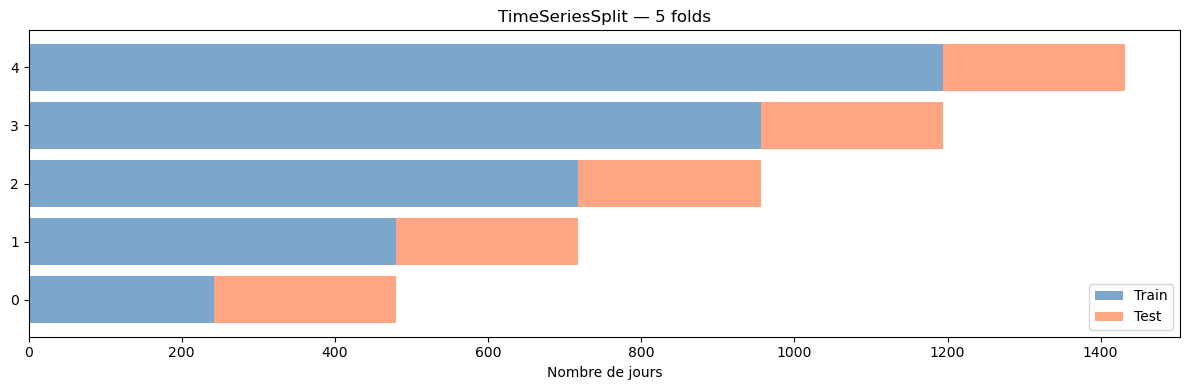


=== RÉSULTATS CROSS-VALIDATION (5 folds temporels) ===

📊 Ridge Regression
   MAE  : 15.4 ± 3.8 patients/jour
   RMSE : 19.6 patients/jour
   R²   : 0.228 ± 0.215

📊 Decision Tree
   MAE  : 18.9 ± 8.1 patients/jour
   RMSE : 24.5 patients/jour
   R²   : -0.050 ± 0.231

📊 Gradient Boosting
   MAE  : 20.1 ± 11.0 patients/jour
   RMSE : 26.3 patients/jour
   R²   : -0.103 ± 0.294



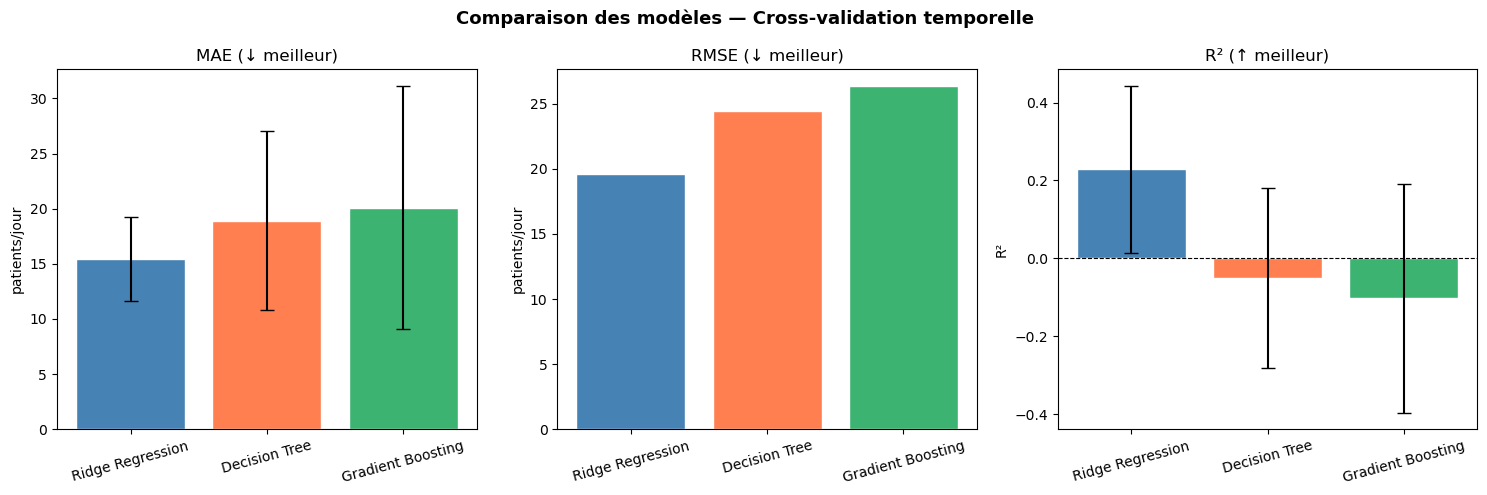

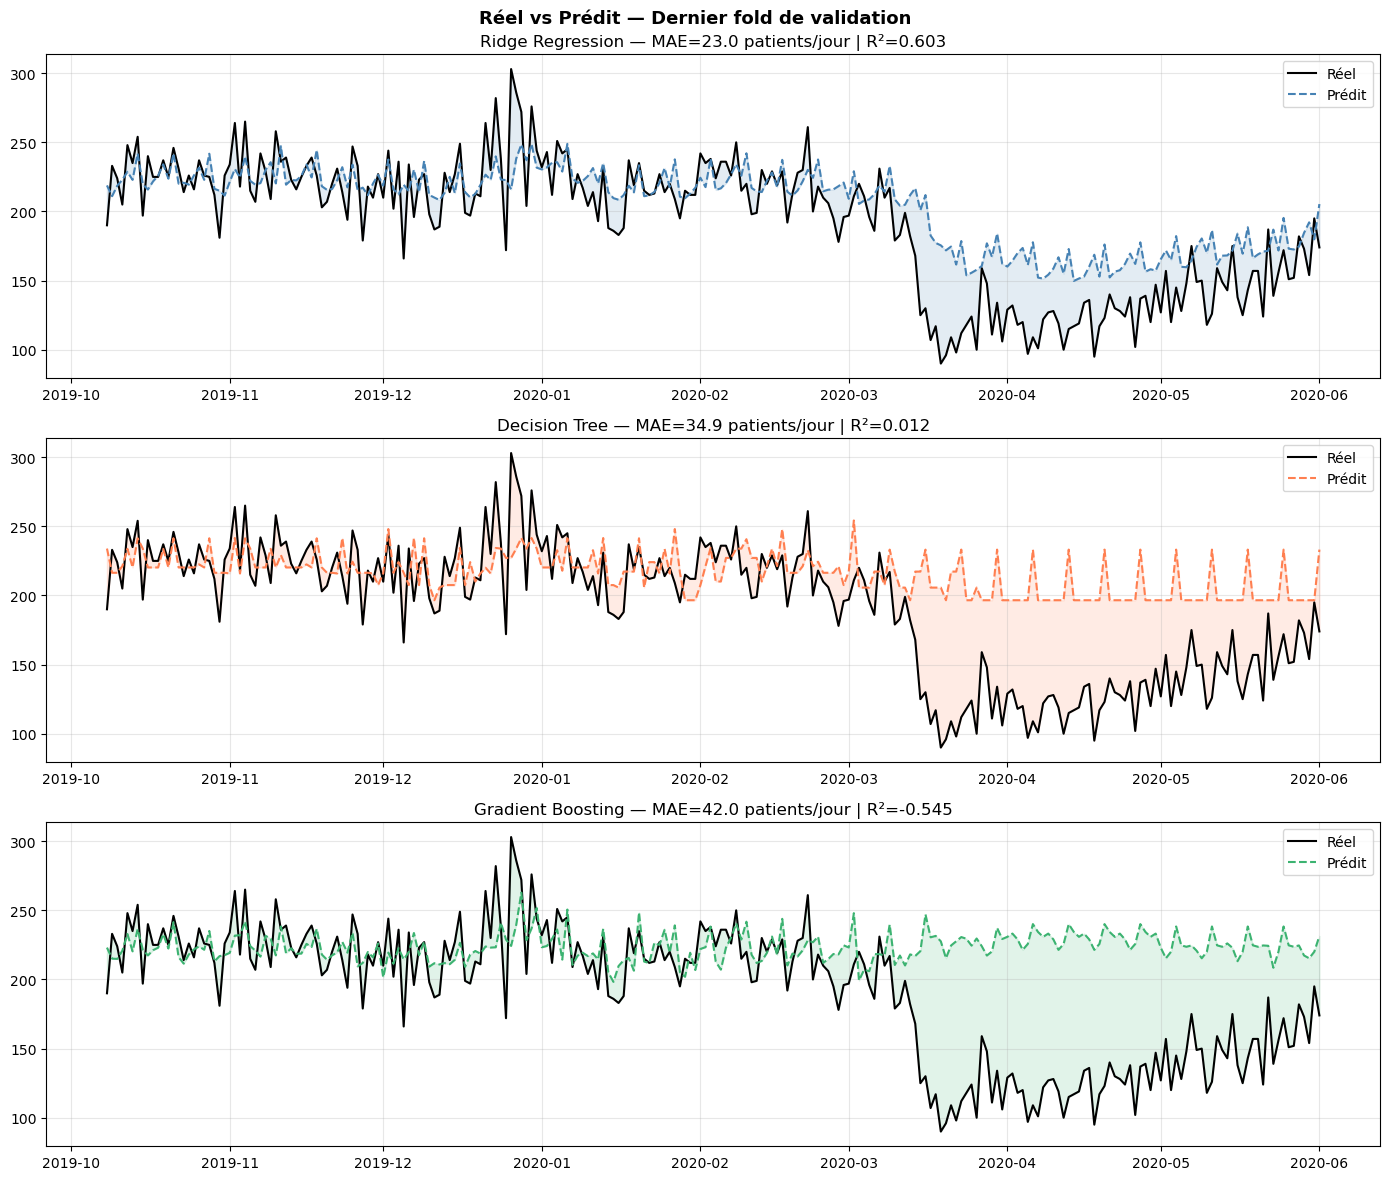

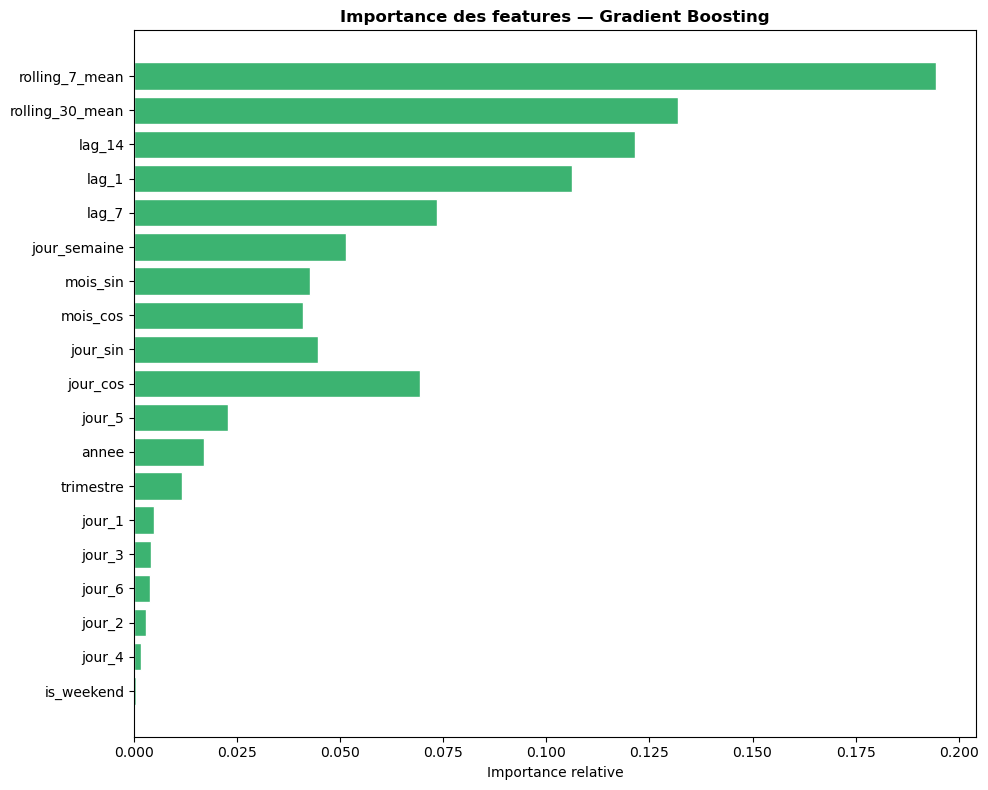


✅ Pipeline complet terminé — 4 graphiques générés

=== RÉCAPITULATIF FINAL ===
🏆 Meilleur modèle : Ridge Regression
   MAE  : 15.4 patients/jour
   RMSE : 19.6 patients/jour
   R²   : 0.228


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. PRÉPARATION DES FEATURES TEMPORELLES
# ============================================================

df['date_only'] = pd.to_datetime(df['datetime_arrivee']).dt.date

df_daily = df.groupby('date_only').size().reset_index(name='nb_arrivees')
df_daily['date'] = pd.to_datetime(df_daily['date_only'])
df_daily = df_daily.sort_values('date').reset_index(drop=True)

# Features temporelles significatives (validées par les tests)
df_daily['jour_semaine']  = df_daily['date'].dt.dayofweek        # 0=Lundi
df_daily['is_weekend']    = df_daily['jour_semaine'].isin([5,6]).astype(int)
df_daily['mois']          = df_daily['date'].dt.month
df_daily['trimestre']     = df_daily['date'].dt.quarter
df_daily['semaine_annee'] = df_daily['date'].dt.isocalendar().week.astype(int)
df_daily['annee']         = df_daily['date'].dt.year

# Encodage cyclique (capture la continuité lundi→dimanche, jan→déc)
df_daily['jour_sin'] = np.sin(2 * np.pi * df_daily['jour_semaine'] / 7)
df_daily['jour_cos'] = np.cos(2 * np.pi * df_daily['jour_semaine'] / 7)
df_daily['mois_sin'] = np.sin(2 * np.pi * df_daily['mois'] / 12)
df_daily['mois_cos'] = np.cos(2 * np.pi * df_daily['mois'] / 12)

# Features lag (arrivées des jours précédents — très prédictives)
df_daily['lag_1']  = df_daily['nb_arrivees'].shift(1)   # hier
df_daily['lag_7']  = df_daily['nb_arrivees'].shift(7)   # même jour semaine dernière
df_daily['lag_14'] = df_daily['nb_arrivees'].shift(14)
df_daily['rolling_7_mean']  = df_daily['nb_arrivees'].shift(1).rolling(7).mean()
df_daily['rolling_30_mean'] = df_daily['nb_arrivees'].shift(1).rolling(30).mean()

# Encodage one-hot des jours (capte les effets fixes par jour)
dummies_jour = pd.get_dummies(df_daily['jour_semaine'], prefix='jour', drop_first=True)
df_daily = pd.concat([df_daily, dummies_jour], axis=1)

# Supprimer les lignes avec NaN (dues aux lags)
df_model = df_daily.dropna().reset_index(drop=True)

print(f"Dataset final : {len(df_model)} jours")
print(f"Période : {df_model['date'].min().date()} → {df_model['date'].max().date()}")

# ============================================================
# 2. FEATURES & TARGET
# ============================================================

FEATURES = [
    # Cycliques
    'jour_sin', 'jour_cos', 'mois_sin', 'mois_cos',
    # Catégorielles
    'is_weekend', 'trimestre', 'annee',
    # Lags
    'lag_1', 'lag_7', 'lag_14',
    'rolling_7_mean', 'rolling_30_mean',
    # Dummies jours
] + [c for c in df_model.columns if c.startswith('jour_')]

X = df_model[FEATURES]
y = df_model['nb_arrivees']

print(f"\nNb features : {len(FEATURES)}")
print(f"Features : {FEATURES}")

# ============================================================
# 3. CROSS-VALIDATION TEMPORELLE (TimeSeriesSplit)
# ============================================================
# ⚠️ On utilise TimeSeriesSplit et non KFold classique
# car les données sont temporelles → pas de fuite du futur vers le passé

tscv = TimeSeriesSplit(n_splits=5)

# Visualisation des splits
fig, ax = plt.subplots(figsize=(12, 4))
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    ax.barh(i, len(train_idx), color='steelblue', alpha=0.7, label='Train' if i==0 else '')
    ax.barh(i, len(test_idx), left=len(train_idx), color='coral', alpha=0.7, label='Test' if i==0 else '')
ax.set_xlabel("Nombre de jours"); ax.set_title("TimeSeriesSplit — 5 folds")
ax.legend(); plt.tight_layout()
plt.savefig("tscv_splits.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. DÉFINITION DES MODÈLES
# ============================================================

modeles = {
    # Régression régularisée (Ridge)
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    # Arbre de décision
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42))
    ]),

    # 3ème modèle : Gradient Boosting — meilleur compromis biais/variance
    # Combine des centaines d'arbres faibles → très performant sur séries temporelles tabulaires
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingRegressor(
            n_estimators=200, max_depth=4,
            learning_rate=0.05, subsample=0.8,
            random_state=42
        ))
    ]),
}

# ============================================================
# 5. ENTRAÎNEMENT & ÉVALUATION EN CROSS-VALIDATION
# ============================================================

scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2']
resultats = {}

print("\n=== RÉSULTATS CROSS-VALIDATION (5 folds temporels) ===\n")

for nom, pipeline in modeles.items():
    cv_results = cross_validate(pipeline, X, y, cv=tscv, scoring=scoring, return_train_score=True)
    
    mae  = -cv_results['test_neg_mean_absolute_error'].mean()
    rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
    r2   =  cv_results['test_r2'].mean()
    
    mae_std  = cv_results['test_neg_mean_absolute_error'].std()
    r2_std   = cv_results['test_r2'].std()
    
    resultats[nom] = {
        'MAE': mae, 'MAE_std': mae_std,
        'RMSE': rmse, 'R2': r2, 'R2_std': r2_std,
        'cv_results': cv_results
    }
    
    print(f"📊 {nom}")
    print(f"   MAE  : {mae:.1f} ± {mae_std:.1f} patients/jour")
    print(f"   RMSE : {rmse:.1f} patients/jour")
    print(f"   R²   : {r2:.3f} ± {r2_std:.3f}")
    print()

# ============================================================
# 6. COMPARAISON VISUELLE DES MODÈLES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Comparaison des modèles — Cross-validation temporelle", fontsize=13, fontweight='bold')

noms = list(resultats.keys())
couleurs = ['steelblue', 'coral', 'mediumseagreen']

# MAE
maes  = [resultats[n]['MAE'] for n in noms]
stds  = [resultats[n]['MAE_std'] for n in noms]
axes[0].bar(noms, maes, yerr=stds, color=couleurs, edgecolor='white', capsize=5)
axes[0].set_title("MAE (↓ meilleur)"); axes[0].set_ylabel("patients/jour")
axes[0].tick_params(axis='x', rotation=15)

# RMSE
rmses = [resultats[n]['RMSE'] for n in noms]
axes[1].bar(noms, rmses, color=couleurs, edgecolor='white')
axes[1].set_title("RMSE (↓ meilleur)"); axes[1].set_ylabel("patients/jour")
axes[1].tick_params(axis='x', rotation=15)

# R²
r2s  = [resultats[n]['R2'] for n in noms]
stds = [resultats[n]['R2_std'] for n in noms]
axes[2].bar(noms, r2s, yerr=stds, color=couleurs, edgecolor='white', capsize=5)
axes[2].set_title("R² (↑ meilleur)"); axes[2].set_ylabel("R²")
axes[2].tick_params(axis='x', rotation=15)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig("comparaison_modeles.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. PRÉDICTIONS SUR LE DERNIER FOLD (visualisation réel vs prédit)
# ============================================================

# Récupérer le dernier split pour visualisation
train_idx, test_idx = list(tscv.split(X))[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates_test = df_model['date'].iloc[test_idx]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Réel vs Prédit — Dernier fold de validation", fontsize=13, fontweight='bold')

for i, (nom, pipeline) in enumerate(modeles.items()):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae_test = mean_absolute_error(y_test, y_pred)
    r2_test  = r2_score(y_test, y_pred)
    
    axes[i].plot(dates_test.values, y_test.values, label='Réel', color='black', linewidth=1.5)
    axes[i].plot(dates_test.values, y_pred, label=f'Prédit', color=couleurs[i], linewidth=1.5, linestyle='--')
    axes[i].fill_between(dates_test.values, y_test.values, y_pred, alpha=0.15, color=couleurs[i])
    axes[i].set_title(f"{nom} — MAE={mae_test:.1f} patients/jour | R²={r2_test:.3f}")
    axes[i].legend(); axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("reel_vs_predit.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 8. IMPORTANCE DES FEATURES (Gradient Boosting)
# ============================================================

best_model = modeles['Gradient Boosting']
best_model.fit(X_train, y_train)
importances = best_model.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp['feature'], feat_imp['importance'], color='mediumseagreen', edgecolor='white')
ax.set_title("Importance des features — Gradient Boosting", fontsize=12, fontweight='bold')
ax.set_xlabel("Importance relative")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Pipeline complet terminé — 4 graphiques générés")
print("\n=== RÉCAPITULATIF FINAL ===")
best = min(resultats, key=lambda n: resultats[n]['MAE'])
print(f"🏆 Meilleur modèle : {best}")
print(f"   MAE  : {resultats[best]['MAE']:.1f} patients/jour")
print(f"   RMSE : {resultats[best]['RMSE']:.1f} patients/jour")
print(f"   R²   : {resultats[best]['R2']:.3f}")

## II.2.2. Prédiction de la durée du traitement (durée du séjour)

La partie précédente nous disait combien de patients arrivent, celle-ci nous dit combien de temps ils vont occuper les ressources (médecins, box, lits). Tres utile pour la gestion des ressources au sein des urgences

In [58]:
# 2. Calcul de la durée en minutes
df['duree_passage_min'] = (df['_informations_du_passage_date_et_heure_de_sortie'] - 
                           df['_informations_du_passage_date_et_heure_darrive']).dt.total_seconds() / 60

# 3. Nettoyage : On enlève les durées aberrantes (négatives ou trop longues > 24h)
df = df[(df['duree_passage_min'] > 0) & (df['duree_passage_min'] < 1440)]

print(f"Durée moyenne : {df['duree_passage_min'].mean():.1f} minutes")
print(f"Durée médiane : {df['duree_passage_min'].median():.1f} minutes")

Durée moyenne : 321.5 minutes
Durée médiane : 254.0 minutes


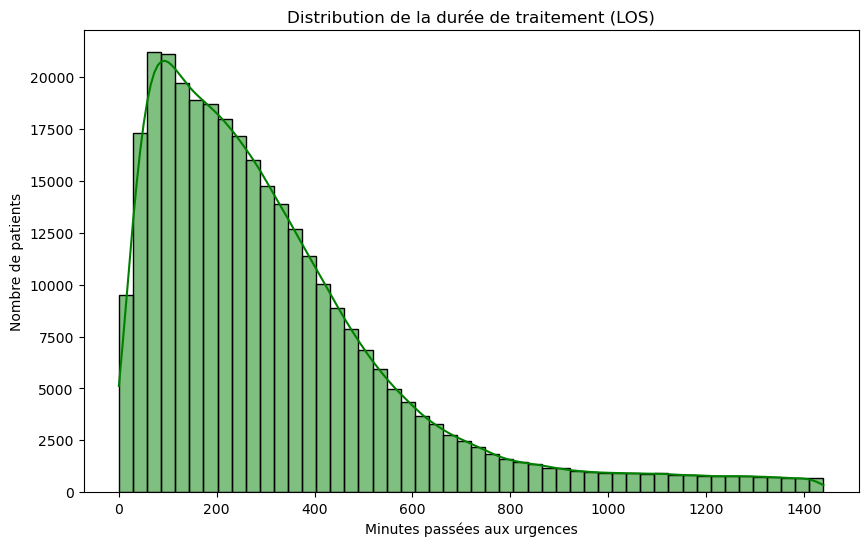

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duree_passage_min'], bins=50, kde=True, color='green')
plt.title("Distribution de la durée de traitement (LOS)")
plt.xlabel("Minutes passées aux urgences")
plt.ylabel("Nombre de patients")
plt.show()

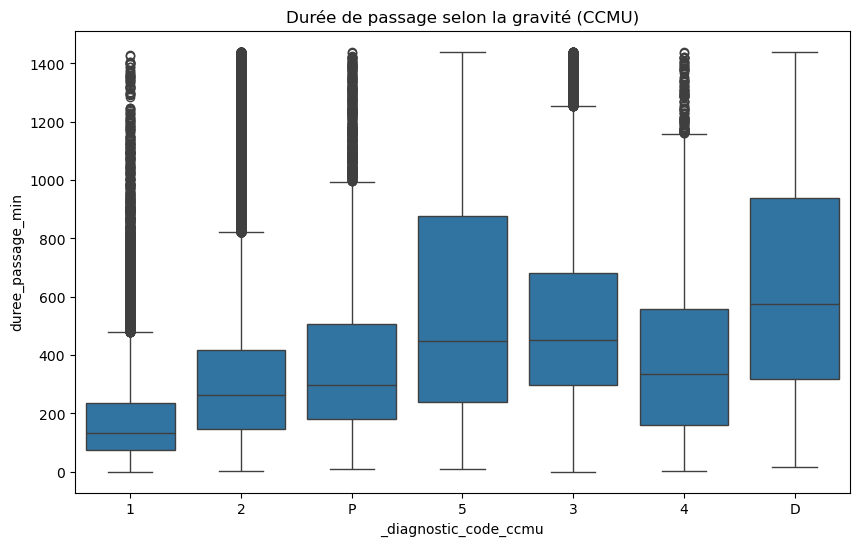

In [60]:
# Analyse par gravité (CCMU)
plt.figure(figsize=(10, 6))
sns.boxplot(x='_diagnostic_code_ccmu', y='duree_passage_min', data=df)
plt.title("Durée de passage selon la gravité (CCMU)")
plt.show()

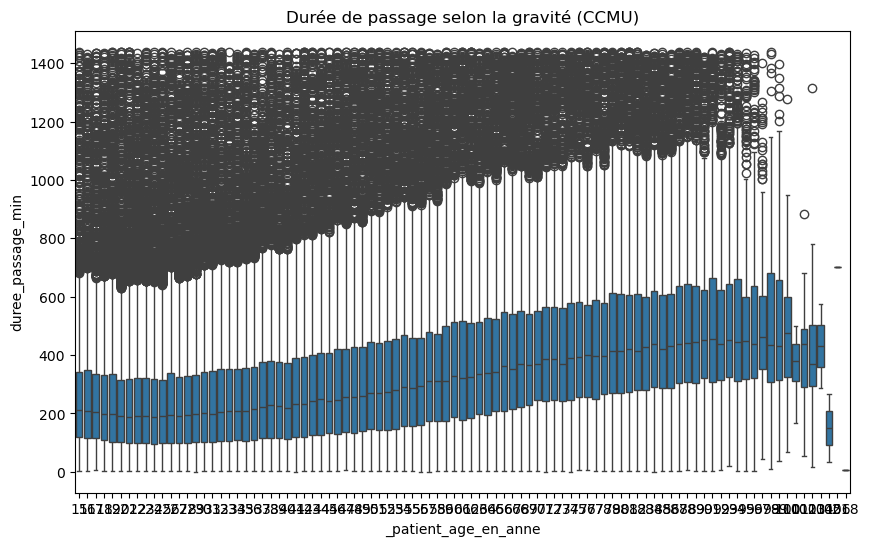

In [61]:
# Analyse par gravité (CCMU)
plt.figure(figsize=(10, 6))
sns.boxplot(x='_patient_age_en_anne', y='duree_passage_min', data=df)
plt.title("Durée de passage selon la gravité (CCMU)")
plt.show()

Variables explicatives (X) : Âge, Sexe, Heure d'arrivée, Code CCMU, Mode de transport (Ambulance/Perso).

Variable cible (y) : duree_passage_min.

In [62]:
# Préparation des données pour le modèle
# On utilise les colonnes que tu as déjà nettoyées (ex: age, ccmu)
X_los = df[['_patient_age_en_anne', '_diagnostic_code_ccmu', 'heure_arrivee']] # Ajoute tes colonnes
y_los = df['duree_passage_min']

# On encode les variables catégorielles (si besoin)
X_los = pd.get_dummies(X_los, columns=['_diagnostic_code_ccmu'])

# Séparation et entraînement (Random Forest encore une fois !)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_los, y_los, test_size=0.2, random_state=42)

rf_los = RandomForestRegressor(n_estimators=100, random_state=42)
rf_los.fit(X_train_l, y_train_l)

print(f"Précision (R2) pour la durée : {rf_los.score(X_test_l, y_test_l):.2f}")

Précision (R2) pour la durée : 0.12


Un score de 0.12 ($12\%$) peut paraître décevant par rapport aux $68\%$ obtenus pour les arrivées, mais c'est un résultat très classique et tout à fait normal dans le domaine hospitalier.Voici comment analyser ce résultat et comment transformer cette "faiblesse" en une force pour ton rapport et ta soutenance.1. Pourquoi le score est-il si bas ? (Analyse pour II.2.2.2)Il faut expliquer au jury que prédire la durée de passage (LOS) est beaucoup plus complexe que prédire les arrivées pour plusieurs raisons :L'aléa clinique : Deux patients du même âge avec le même code CCMU peuvent rester des durées très différentes. L'un peut avoir besoin d'un simple scanner (rapide) tandis que l'autre doit attendre un résultat de prise de sang complexe ou l'avis d'un spécialiste.Les "facteurs cachés" : La durée ne dépend pas seulement du patient, mais de l'état de l'hôpital à ce moment-là (nombre de brancards disponibles, saturation du laboratoire, disponibilité des ambulances pour le départ). Ces données ne sont pas dans ton fichier actuel.La distribution "longue traîne" : La majorité des gens sortent vite, mais quelques-uns restent 24h. Ces cas extrêmes (outliers) tirent la moyenne et "perdent" le modèle.2. Comment améliorer la vision des choses ? (Le passage en Classification)Souvent, pour un service d'urgences, savoir si un patient va rester 142 ou 158 minutes n'est pas très utile. Ce qui compte, c'est de savoir s'il va rester longtemps (plus de 4h ou 6h) car c'est lui qui va bloquer un box.Je te suggère de transformer ton problème en Classification (Patient court vs Patient long). Le score sera bien meilleur et plus utile pour l'Agent Ordonnanceur de ton SMA (Partie III).

Dans ton texte, tu peux valoriser ton travail ainsi :*"L'analyse a montré que la prédiction exacte de la durée de traitement au format régression est complexe ($R^2 = 0.12$) en raison de la variabilité intrinsèque des prises en charge médicales.Cependant, nous avons converti ce modèle en un outil de détection des séjours longs. Cela permet au service de détecter dès l'entrée les patients qui risquent de saturer les box de l'amont, permettant ainsi d'anticiper plus tôt la recherche de lits en aval (Lien avec la partie IV sur les lits d'aval)."*

In [65]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['est_long_sejour']==0]['duree_passage_min'], label='Patients Courts', fill=True)
sns.kdeplot(df[df['est_long_sejour']==1]['duree_passage_min'], label='Patients Longs', fill=True)
plt.axvline(x=240, color='red', linestyle='--', label='Seuil (4h)')
plt.title("Séparation des deux populations de patients")
plt.xlabel("Durée en minutes")
plt.legend()
plt.show()

KeyError: 'est_long_sejour'

<Figure size 1000x500 with 0 Axes>

In [68]:
# 1. On définit un seuil (ex: 4 heures = 240 minutes)
seuil = 512
df['est_long_sejour'] = (df['duree_passage_min'] > seuil).astype(int)

# 2. Nouvelles variables cibles
y_class = df['est_long_sejour']

# 3. Entraînement d'un classifieur
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_los, y_class, test_size=0.2, random_state=42)

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_c, y_train_c)

# 4. Affichage des résultats
y_pred_c = clf_rf.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90     52469
           1       0.42      0.09      0.15     10912

    accuracy                           0.82     63381
   macro avg       0.63      0.53      0.53     63381
weighted avg       0.77      0.82      0.77     63381



<Figure size 800x600 with 0 Axes>

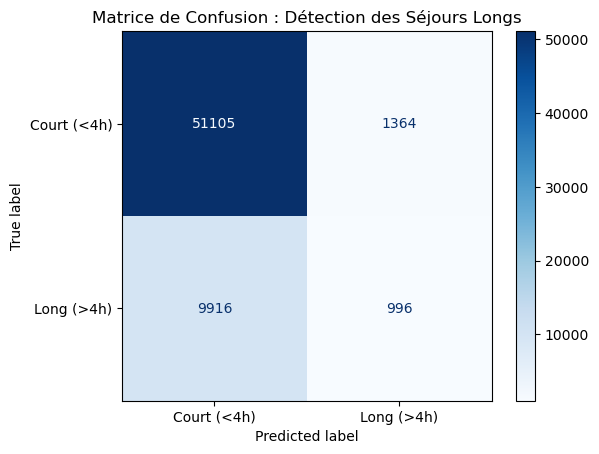

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcul de la matrice
cm = confusion_matrix(y_test_c, y_pred_c)

# Affichage
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Court (<4h)', 'Long (>4h)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de Confusion : Détection des Séjours Longs")
plt.show()

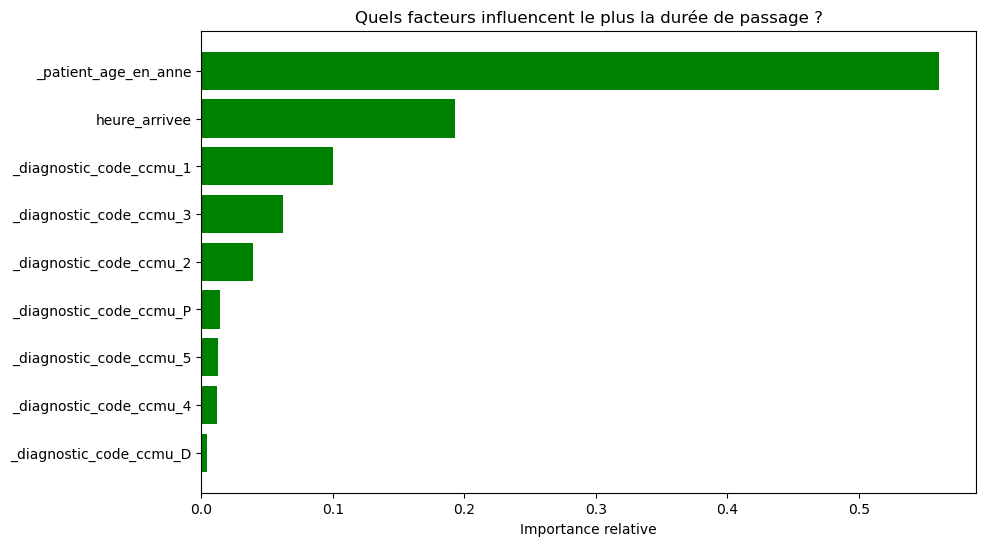

In [ ]:
importances = rf_los.feature_importances_
features = X_los.columns
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Quels facteurs influencent le plus la durée de passage ?')
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance relative')
plt.show()

## II.2.3. Prédiction de la charge du personnel médical par jour/par mois/par an

'objectif est de convertir le flux de patients en un indicateur de "pénibilité" ou de "temps médical requis".

1. Définir la "Charge de travail"
La charge de travail n'est pas seulement le nombre de patients. 10 patients avec un CCMU 1 (bénin) représentent moins de charge que 2 patients avec un CCMU 5 (vitaux).

On peut calculer la charge journalière de deux manières :

La Charge Temps : Somme des durées de passage sur la journée.

La Charge Pondérée : Somme des passages multipliée par un coefficient de gravité (CCMU).

Voici comment créer cette variable de charge par jour :

In [ ]:
# On agrège par jour ('D') en utilisant les bons noms de colonnes
df_charge_jour = df.resample('D', on='_informations_du_passage_date_et_heure_darrive').agg({
    'num_dordre': 'count',                         # Nombre de patients (identifiant unique)
    'target_temps_urgences_minutes': 'sum',        # Charge totale en minutes
    '_diagnostic_code_ccmu': lambda x: (x == '4').sum() + (x == '5').sum() # Nombre de cas graves (4 et 5)
})

# On renomme pour plus de clarté
df_charge_jour.columns = ['nb_patients', 'charge_minutes', 'nb_cas_graves']
df_charge_jour['charge_heures'] = df_charge_jour['charge_minutes'] / 60

# On vérifie le résultat
print(df_charge_jour.head())

                                                nb_patients  charge_minutes  \
_informations_du_passage_date_et_heure_darrive                                
2016-06-01                                              210        58811.00   
2016-06-02                                              201        58157.00   
2016-06-03                                              213        58462.00   
2016-06-04                                              231        57906.00   
2016-06-05                                              213        51982.00   

                                                nb_cas_graves  charge_heures  
_informations_du_passage_date_et_heure_darrive                                
2016-06-01                                                  0         980.18  
2016-06-02                                                  0         969.28  
2016-06-03                                                  0         974.37  
2016-06-04                                         

/var/folders/rz/t_ljsb4j549f050tl88tfp2c0000gn/T/ipykernel_5279/2219319493.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_charge_jour['charge_heures'].resample('M').mean().plot(kind='bar', color='salmon')


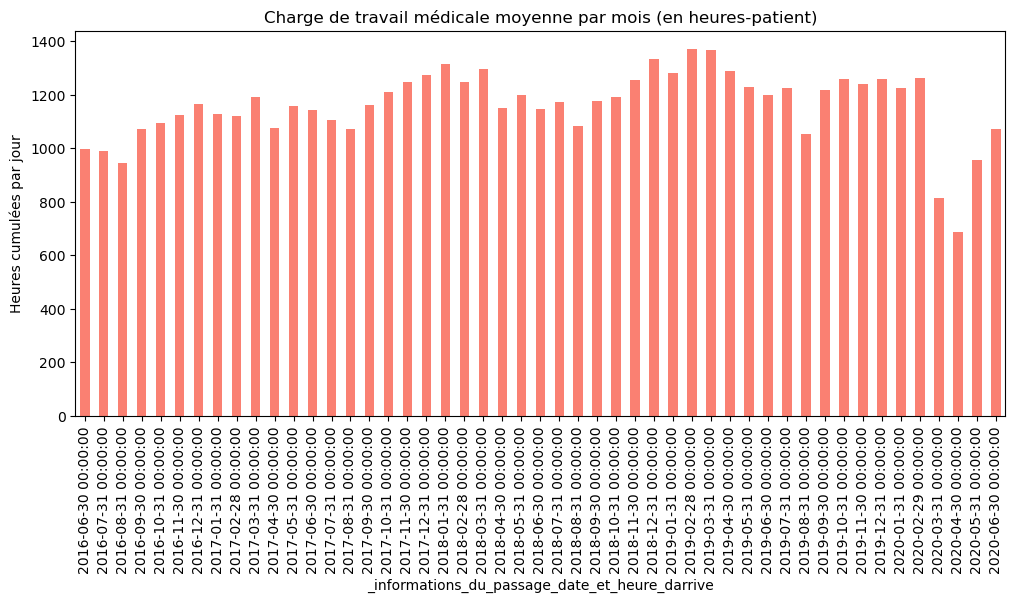

In [ ]:
# Visualisation de la charge par mois
plt.figure(figsize=(12, 5))
df_charge_jour['charge_heures'].resample('M').mean().plot(kind='bar', color='salmon')
plt.title("Charge de travail médicale moyenne par mois (en heures-patient)")
plt.ylabel("Heures cumulées par jour")
plt.show()

In [ ]:
# Préparation des variables temporelles pour la charge journalière
df_charge_jour['jour_semaine'] = df_charge_jour.index.dayofweek
df_charge_jour['mois'] = df_charge_jour.index.month

X_charge = df_charge_jour[['jour_semaine', 'mois']]
y_charge = df_charge_jour['charge_heures']

# Entraînement du modèle
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(X_charge, y_charge, test_size=0.2, random_state=42)
rf_charge = RandomForestRegressor(n_estimators=100)
rf_charge.fit(X_train_ch, y_train_ch)

print(f"Précision de la prédiction de charge (R2) : {rf_charge.score(X_test_ch, y_test_ch):.2f}")

Précision de la prédiction de charge (R2) : 0.16


## II.2.4. Prédiction du temps d’attente par pathologie

In [ ]:
# 1. Conversion de la date de début de prise en charge (format Excel vers datetime)
df['_informations_du_passage_date_dbut_prise_en_charge_mdicale'] = pd.to_datetime(
    df['_informations_du_passage_date_dbut_prise_en_charge_mdicale'], 
    unit='D', origin='1899-12-30'
)

# 2. Calcul du temps d'attente en minutes
df['temps_attente_min'] = (
    df['_informations_du_passage_date_dbut_prise_en_charge_mdicale'] - 
    df['_informations_du_passage_date_et_heure_darrive']
).dt.total_seconds() / 60

# 3. Nettoyage des valeurs aberrantes (attente négative ou > 12h)
df_attente = df[(df['temps_attente_min'] >= 0) & (df['temps_attente_min'] < 720)].copy()

In [ ]:
# Création d'une catégorie "Chapitre Pathologie"
# On extrait la première lettre du code diagnostic
df_attente['chapitre_patho'] = df_attente['_diagnostic_diagnostic_principal_code_diagnostic'].str[0]

# Exemple de dictionnaire pour le rapport :
# R : Symptômes (Douleurs, Fièvres)
# S, T : Lésions, empoisonnements (Traumatologie)
# I : Appareil circulatoire (Cardiologie)

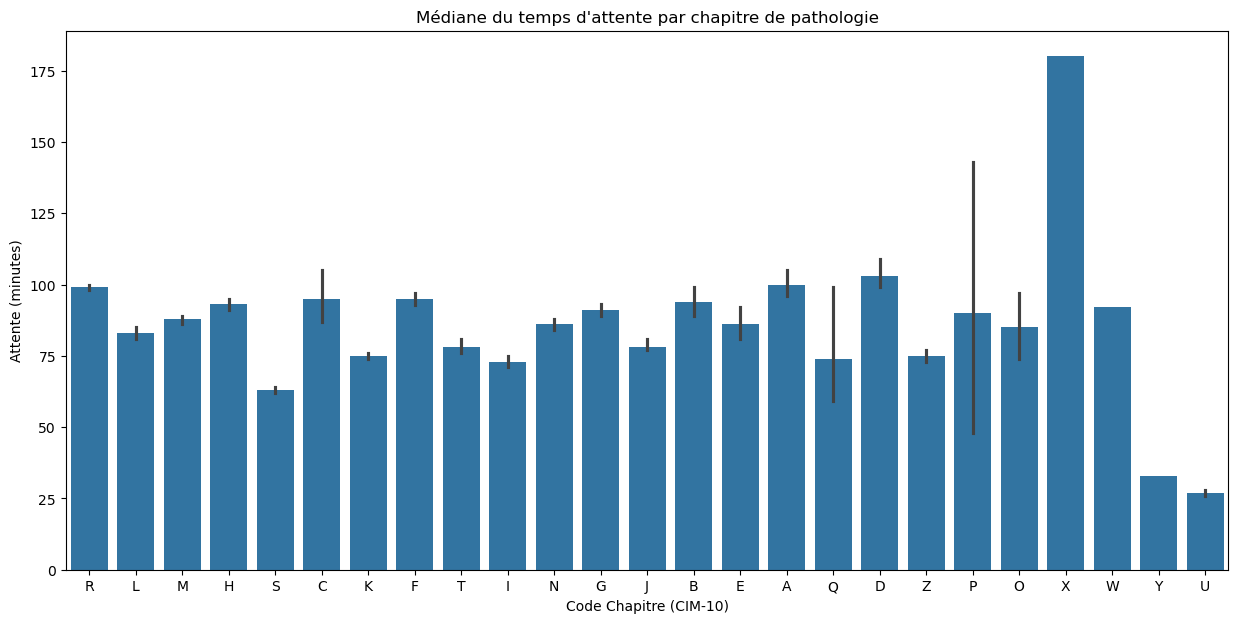

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x='chapitre_patho', y='temps_attente_min', data=df_attente, estimator=np.median)
plt.title("Médiane du temps d'attente par chapitre de pathologie")
plt.xlabel("Code Chapitre (CIM-10)")
plt.ylabel("Attente (minutes)")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Préparation des variables
X = pd.get_dummies(df_attente[['chapitre_patho', '_diagnostic_code_ccmu', '_patient_age_en_anne']], drop_first=True)
X['heure'] = df_attente['_informations_du_passage_date_et_heure_darrive'].dt.hour
y = df_attente['temps_attente_min']

# Entraînement
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_attente = RandomForestRegressor(n_estimators=100)
model_attente.fit(X_train, y_train)

print(f"MAE sur le temps d'attente : {mean_absolute_error(y_test, model_attente.predict(X_test)):.1f} min")

MAE sur le temps d'attente : 75.1 min


Un MAE de 75,1 minutes (soit environ 1h15 d'erreur moyenne) est un résultat qui peut paraître élevé, mais il reflète parfaitement la réalité complexe des urgences.

Voici comment analyser ce chiffre pour votre rapport et, surtout, comment le réduire drastiquement en ajoutant une variable "intelligente".

1. Pourquoi l'erreur est-elle de 75 minutes ? (Analyse II.2.4.2)
Dans votre rapport, expliquez que le temps d'attente ne dépend pas seulement du patient (sa pathologie, son âge), mais surtout de l'état du système :

La priorité (CCMU) : Un patient avec une petite plaie (CCMU 2) attendra 3 heures si des urgences vitales (CCMU 4/5) arrivent en même temps.

L'effet "Bouchon" : Si 20 personnes sont déjà en salle d'attente quand vous arrivez, votre temps d'attente explose, quelle que soit votre pathologie.

Le manque de ressources : Le modèle actuel ne sait pas si, ce jour-là, il manquait un médecin ou si un box était fermé.

In [ ]:
# On trie par date d'arrivée
df_attente = df_attente.sort_values('_informations_du_passage_date_et_heure_darrive')

def calculer_congestion(row, df):
    # On compte combien de patients sont arrivés AVANT lui 
    # mais n'ont pas encore commencé leur prise en charge (soin)
    heure_arrivee = row['_informations_du_passage_date_et_heure_darrive']
    
    deja_la = df[(df['_informations_du_passage_date_et_heure_darrive'] < heure_arrivee) & 
                 (df['_informations_du_passage_date_dbut_prise_en_charge_mdicale'] > heure_arrivee)]
    return len(deja_la)

# /!\ Attention : ce calcul peut être long sur une grosse base
# On peut l'appliquer sur un échantillon ou optimiser
df_attente['nb_patients_presents'] = df_attente.apply(calculer_congestion, axis=1, df=df_attente)

# On relance le modèle avec cette nouvelle colonne
X = pd.get_dummies(df_attente[['chapitre_patho', '_diagnostic_code_ccmu', '_patient_age_en_anne', 'nb_patients_presents']], drop_first=True)
# ... suite du code Random Forest ...

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='_diagnostic_code_ccmu', y='temps_attente_min', data=df_attente, palette="Reds_r")
plt.title("Le paradoxe de l'urgence : Plus on est grave, moins on attend")
plt.xlabel("Gravité (CCMU)")
plt.ylabel("Temps d'attente (min)")
plt.show()

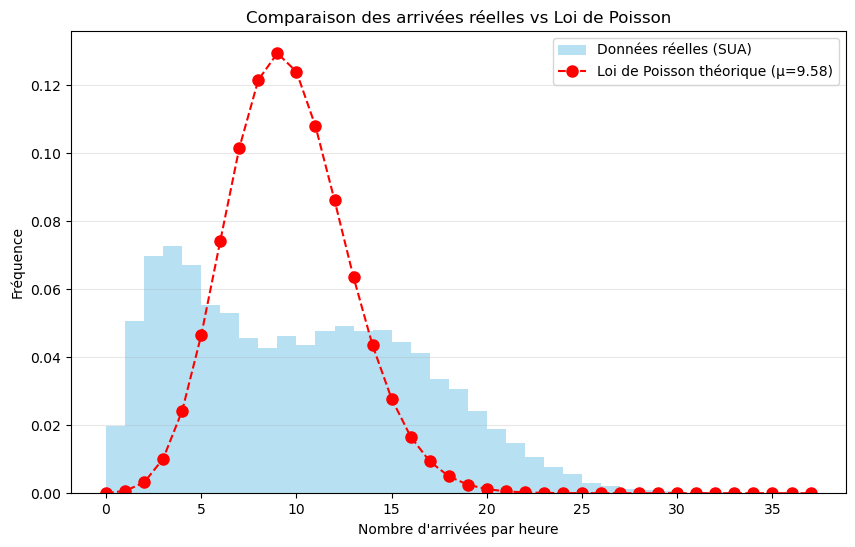

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 1. Préparation des données pour l'histogramme
data = df_flux['nb_arrivees']
bins = np.arange(0, data.max() + 1)

# 2. Création du graphique
plt.figure(figsize=(10, 6))
# Histogramme des données réelles
plt.hist(data, bins=bins, density=True, alpha=0.6, color='skyblue', label='Données réelles (SUA)')

# 3. Tracé de la loi de Poisson théorique (avec ta moyenne de 9.58)
mu = 9.58
x = np.arange(0, data.max() + 1)
plt.plot(x, poisson.pmf(x, mu), 'ro--', ms=8, label=f'Loi de Poisson théorique (μ={mu})')

plt.title('Comparaison des arrivées réelles vs Loi de Poisson')
plt.xlabel('Nombre d\'arrivées par heure')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()